In [160]:
# School EDA: 5 advanced visuals (ready to run)
# Requirements: pandas, numpy, matplotlib, scikit-learn, nbformat (optional)
# Make sure these packages are installed in your environment.

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.inspection import PartialDependenceDisplay

# ---------- USER CONFIG ----------
csv_path = "/Users/robbannn/Desktop/SEM_5/DV_PROJECT/public-census_oct_2018.csv"
outdir = "./school_eda_outputs"
os.makedirs(outdir, exist_ok=True)
# ----------------------------------

# --- utils ---
def safe_read(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found at path: {path}. Please check path.")
    return pd.read_csv(path, low_memory=False)

def coerce_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

# --- Load dataset ---
try:
    df = safe_read(csv_path)
except Exception as e:
    raise SystemExit(f"Could not read csv at {csv_path}. Error: {e}")

# --- Basic cleaning / derived metrics ---
df.columns = df.columns.str.strip()

# Convert typical numeric columns
numeric_cols = [
    "na_no","pp_no","uc_no","est_year","total_rooms","functional_classrooms",
    "total_toilets","usable_toilets","total_computers","enrollment",
    "Teachers","total_area_kanal","total_area_marla","covered_area"
]
coerce_numeric(df, numeric_cols)

# ensure enrollment numeric and fill zeros where appropriate
df['enrollment'] = pd.to_numeric(df['enrollment'], errors='coerce').fillna(0)

# Derived per-student metrics (safely)
df['students_per_functional_classroom'] = df.apply(
    lambda r: (r['enrollment'] / r['functional_classrooms'])
    if pd.notna(r.get('functional_classrooms')) and r.get('functional_classrooms') and r['functional_classrooms']>0 else np.nan,
    axis=1
)
df['usable_toilets_per_100_students'] = df.apply(
    lambda r: (r['usable_toilets'] / r['enrollment'] * 100)
    if pd.notna(r.get('usable_toilets')) and r.get('enrollment') and r['enrollment']>0 else np.nan,
    axis=1
)
df['computers_per_100_students'] = df.apply(
    lambda r: (r.get('total_computers',0) / r['enrollment'] * 100)
    if pd.notna(r.get('total_computers')) and r.get('enrollment') and r['enrollment']>0 else np.nan,
    axis=1
)
df['classroom_utilization_index'] = df['functional_classrooms'] / df['total_rooms'].replace(0, np.nan)

# Encode building condition into a score (simple heuristic)
def encode_bldg_condition(x):
    if pd.isna(x): return np.nan
    s = str(x).lower()
    if "satisf" in s or "satisfying" in s or "good" in s: return 1.0
    if "needed minor" in s or "minor" in s or "needed" in s: return 0.5
    if "bad" in s or "rough" in s or "needed major" in s or "completely rough" in s: return 0.0
    return np.nan

if 'bldg_condition' in df.columns:
    df['bldg_condition_score'] = df['bldg_condition'].apply(encode_bldg_condition)
else:
    df['bldg_condition_score'] = np.nan

# Binary resource flags
df['has_library'] = df.get('library').apply(lambda x: 1 if pd.notna(x) and str(x).strip().lower() not in ('0','no','not available','') else 0) if 'library' in df.columns else 0
df['has_electricity'] = df.get('electricity').apply(lambda x: 1 if str(x).strip().lower() in ('1','yes','available','wapda connection') else 0) if 'electricity' in df.columns else 0
df['has_playground'] = df.get('play_ground').apply(lambda x: 1 if str(x).strip().lower() in ('1','yes','available','completed') else 0) if 'play_ground' in df.columns else 0

# Compose a School Quality Index (weighted, interpretable)
# weights chosen to reflect sanitary, infrastructure, teaching space, digital access, and library
df['toilets_100_scaled'] = df['usable_toilets_per_100_students'].clip(0,10)/10
# inverse students per classroom (higher is better); baseline 30 pupils
df['students_per_class_inv'] = df['students_per_functional_classroom'].apply(lambda x: (1/(x/30)) if pd.notna(x) and x>0 else np.nan)
df['students_per_class_inv_scaled'] = df['students_per_class_inv'].replace([np.inf,-np.inf], np.nan).clip(0,2)/2
df['computers_100_scaled'] = df['computers_per_100_students'].clip(0,10)/10
df['library_flag_scaled'] = df['has_library']
df['electricity_flag_scaled'] = df['has_electricity']

df['school_quality_index'] = (
    0.25 * df['bldg_condition_score'].fillna(0) +
    0.20 * df['toilets_100_scaled'].fillna(0) +
    0.25 * df['students_per_class_inv_scaled'].fillna(0) +
    0.15 * df['computers_100_scaled'].fillna(0) +
    0.10 * df['library_flag_scaled'].fillna(0) +
    0.05 * df['electricity_flag_scaled'].fillna(0)
)




/var/folders/0x/rx6z5n5d6dzbfbmmrfbxwsdw0000gn/T/ipykernel_79098/270280131.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=[str(x) for x in top_nas], showfliers=False)


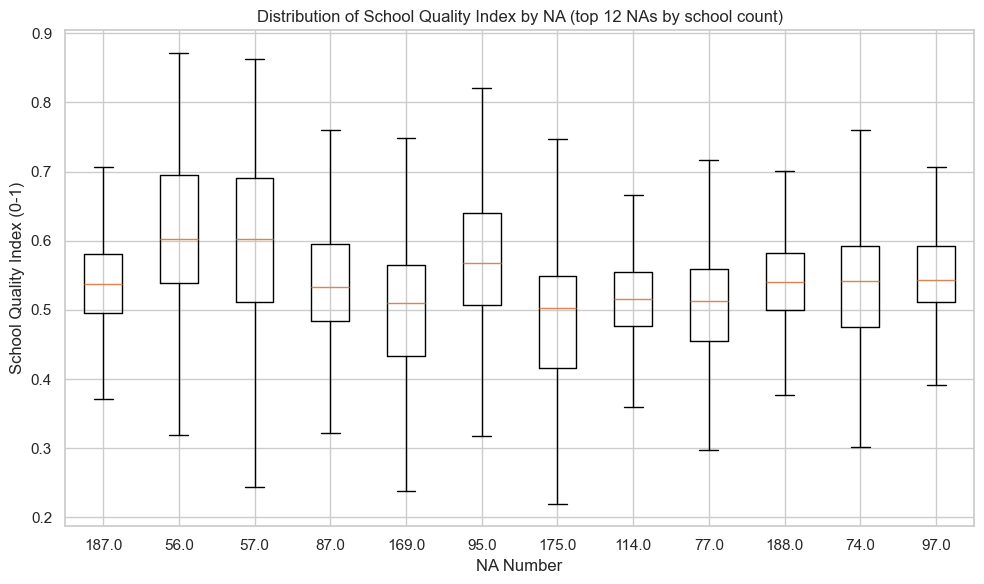

In [161]:
# ---------- VISUAL 1 ----------
# NA-wise distribution of School Quality Index (boxplots of top N NAs by school count)
plt.figure(figsize=(10,6))
if 'na_no' in df.columns:
    na_counts = df['na_no'].value_counts().dropna()
    top_nas = na_counts.nlargest(12).index.astype(str)
    plot_df = df[df['na_no'].astype(str).isin(top_nas)]
    groups = [plot_df[plot_df['na_no'].astype(str)==na]['school_quality_index'].dropna() for na in top_nas]
    plt.boxplot(groups, labels=[str(x) for x in top_nas], showfliers=False)
    plt.title("Distribution of School Quality Index by NA (top 12 NAs by school count)")
    plt.xlabel("NA Number")
    plt.ylabel("School Quality Index (0-1)")
else:
    plt.text(0.5,0.5,"na_no column not found", ha='center')
plt.tight_layout()
plt.savefig(os.path.join(outdir, "na_quality_distribution.png"))
plt.show()

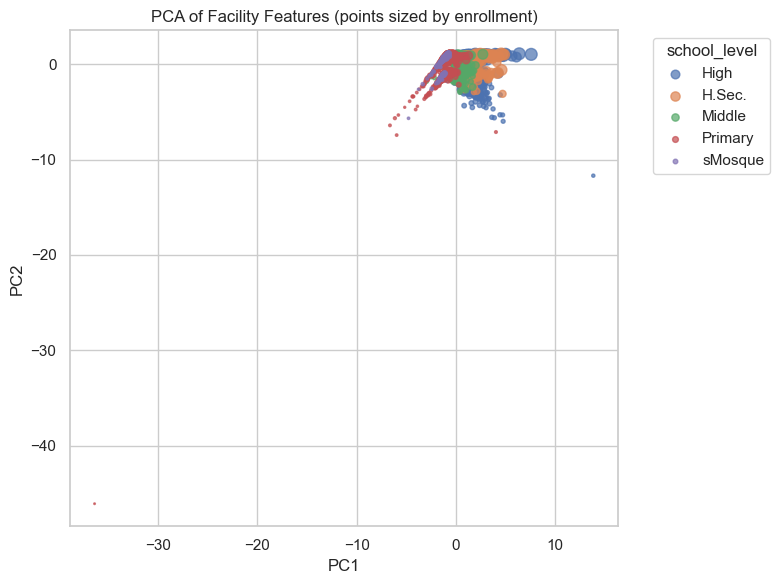

In [162]:
# ---------- VISUAL 2 ----------
# PCA on facilities features, scatter with point size = sqrt(enrollment)
fac_cols = ["functional_classrooms","usable_toilets_per_100_students","computers_per_100_students","bldg_condition_score"]
fac_present = [c for c in fac_cols if c in df.columns]
if len(fac_present) >= 2:
    pca_df = df[fac_present].dropna()
    if not pca_df.empty:
        scaler = StandardScaler()
        Xs = scaler.fit_transform(pca_df.values)
        pca = PCA(n_components=2)
        Xp = pca.fit_transform(Xs)
        pca_plot_df = df.loc[pca_df.index].copy()
        pca_plot_df['PC1'] = Xp[:,0]
        pca_plot_df['PC2'] = Xp[:,1]
        sizes = np.sqrt(pca_plot_df['enrollment'].fillna(1).astype(float)+1)
        plt.figure(figsize=(8,6))
        # plot different school levels separately (to provide multi-dim insight)
        levels = pca_plot_df['school_level'].astype(str).fillna('Unknown').unique()
        for lvl in levels:
            sub = pca_plot_df[pca_plot_df['school_level'].astype(str)==lvl]
            plt.scatter(sub['PC1'], sub['PC2'], s=sizes.loc[sub.index], label=str(lvl), alpha=0.7)
        plt.title("PCA of Facility Features (points sized by enrollment)")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.legend(title='school_level', bbox_to_anchor=(1.05,1), loc='upper left')
        plt.tight_layout()
        plt.savefig(os.path.join(outdir, "pca_facilities.png"))
        plt.show()
    else:
        print("Not enough facility data for PCA.")
else:
    print("Not enough facility columns present for PCA.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("/Users/robbannn/Desktop/SEM_5/DV_PROJECT/public-census_oct_2018.csv")

# Assuming the functional status column is named something like "FUNCTIONAL_STATUS"
# Update this to match your actual column name
status_col = "FUNCTIONAL_STATUS"  

# Count functional vs non-functional schools
status_counts = df["school_status"].value_counts()

print(status_counts )
# Pie chart
plt.figure(figsize=(8,8))
plt.bar(status_counts.values)
plt.title("Functional vs Non-Functional Schools")
plt.axis('equal')  # Ensures pie is a circle
plt.show()


school_status
Functional        52461
Non-Functional        9
Name: count, dtype: int64


/var/folders/0x/rx6z5n5d6dzbfbmmrfbxwsdw0000gn/T/ipykernel_79098/4066444277.py:5: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/robbannn/Desktop/SEM_5/DV_PROJECT/public-census_oct_2018.csv")


TypeError: bar() missing 1 required positional argument: 'height'

<Figure size 800x800 with 0 Axes>

In [164]:
df['non_func_reason'].value_counts(dropna=False).head(30)


non_func_reason
NaN                            48204
0.0                             2752
0                               1502
Building Illegally Occupied        6
Building is Not Constructed        2
Students Not Available             1
Teachers Not Available             1
2                                  1
2.0                                1
Name: count, dtype: int64

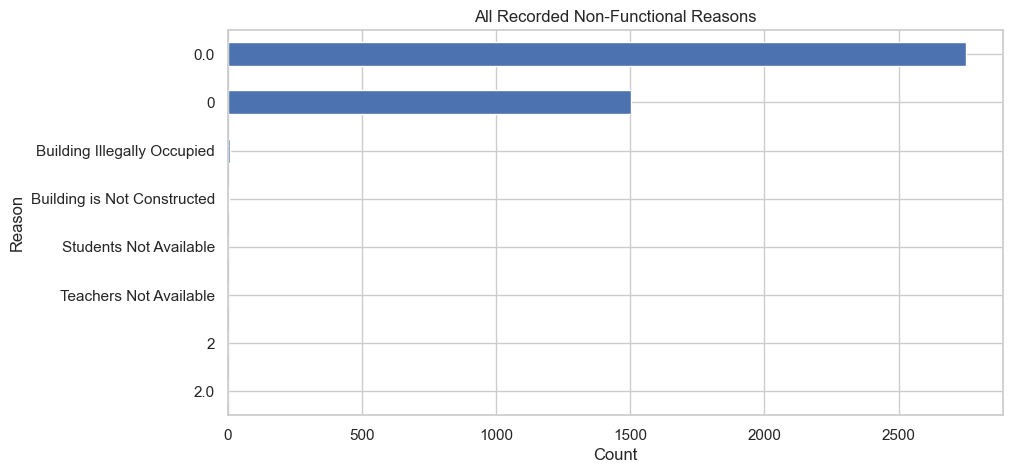

In [165]:

valid_reasons = df['non_func_reason'].dropna()

if len(valid_reasons) == 0:
    print("No valid non-functional reasons found in dataset.")
else:
    reason_counts = valid_reasons.value_counts()

    plt.figure(figsize=(10, 5))
    reason_counts.plot(kind="barh")
    plt.title("All Recorded Non-Functional Reasons")
    plt.xlabel("Count")
    plt.ylabel("Reason")
    plt.gca().invert_yaxis()
    plt.show()



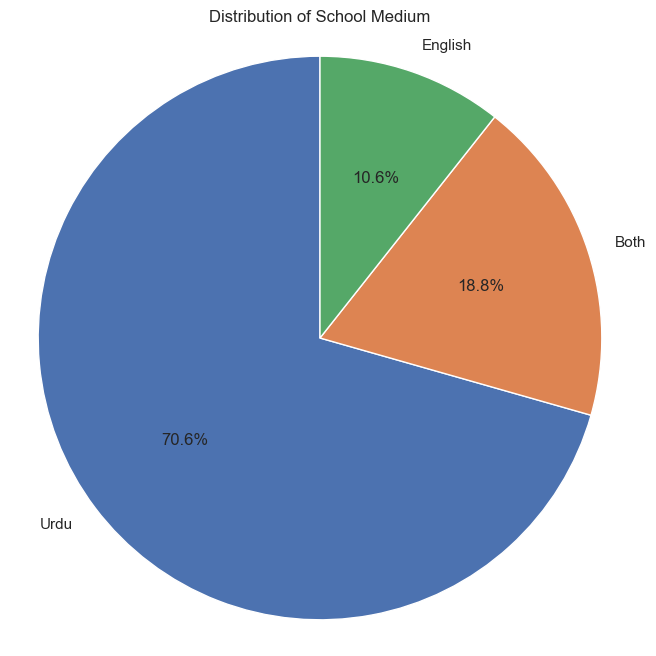

In [166]:
import pandas as pd
import matplotlib.pyplot as plt



# Replace with the actual column name for Medium of Instruction
medium_col = "medium"

# Count medium distribution
medium_counts = df[medium_col].value_counts()

# Pie chart
plt.figure(figsize=(8,8))
plt.pie(medium_counts.values, labels=medium_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of School Medium")
plt.axis('equal')
plt.show()


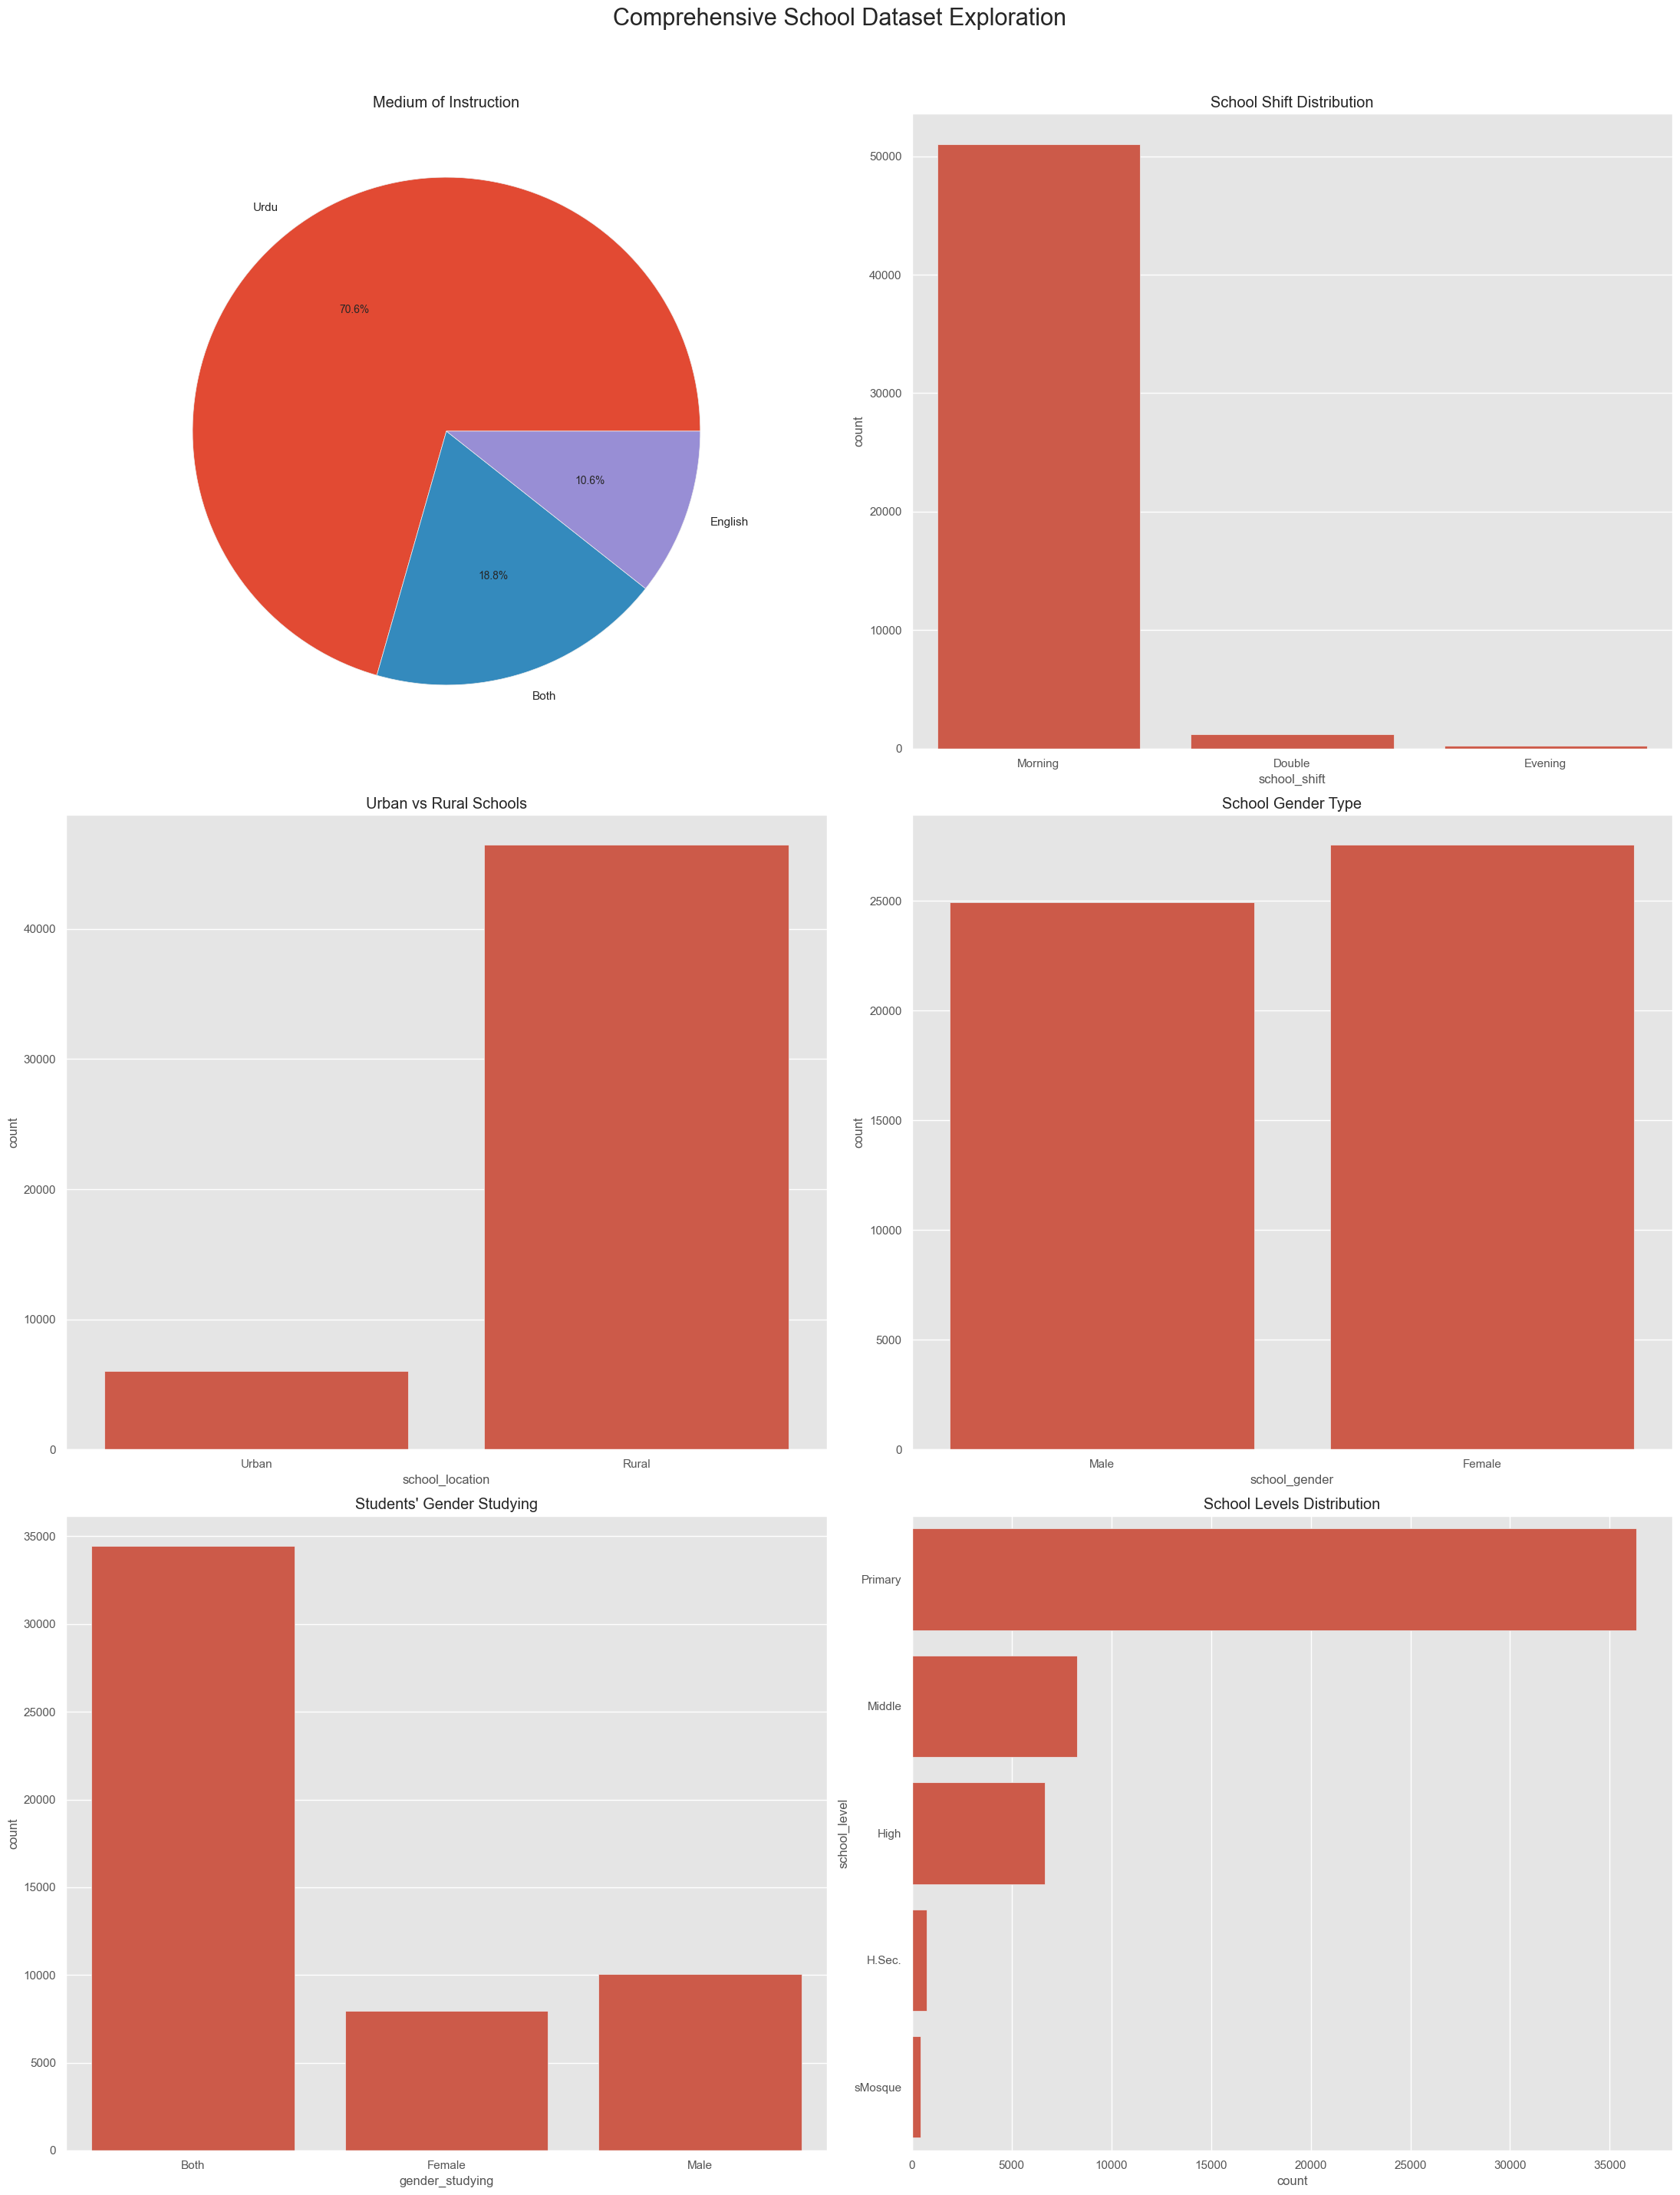

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATA


plt.style.use("ggplot")
fig, axes = plt.subplots(3, 2, figsize=(22, 28))
fig.suptitle("Comprehensive School Dataset Exploration", fontsize=22, y=1.02)

# # --- 1. SCHOOL STATUS ---
# sns.countplot(data=df, x="school_status", ax=axes[0,0])
# axes[0,0].set_title("School Status Distribution")

# --- 2. MEDIUM OF SCHOOL ---
df["medium"].value_counts().plot.pie(
    autopct="%1.1f%%", ax=axes[0,0], ylabel=""
)
axes[0,0].set_title("Medium of Instruction")

# # --- 3. NON-FUNCTIONAL REASON ---
# sns.countplot(data=df, y="non_func_reason", ax=axes[1,0])
# axes[1,0].set_title("Reasons for Non-Functional Schools")

# --- 4. SCHOOL SHIFT ---
sns.countplot(data=df, x="school_shift", ax=axes[0,1])
axes[0,1].set_title("School Shift Distribution")

# --- 5. SCHOOL LOCATION ---
sns.countplot(data=df, x="school_location", ax=axes[1,0])
axes[1,0].set_title("Urban vs Rural Schools")

# --- 6. SCHOOL GENDER ---
sns.countplot(data=df, x="school_gender", ax=axes[1,1])
axes[1,1].set_title("School Gender Type")

# --- 7. GENDER STUDYING ---
sns.countplot(data=df, x="gender_studying", ax=axes[2,0])
axes[2,0].set_title("Students' Gender Studying")

# --- 8. SCHOOL LEVEL ---
sns.countplot(data=df, y="school_level", ax=axes[2,1])
axes[2,1].set_title("School Levels Distribution")

plt.tight_layout()
plt.show()


ValueError: num must be an integer with 1 <= num <= 6, not 7

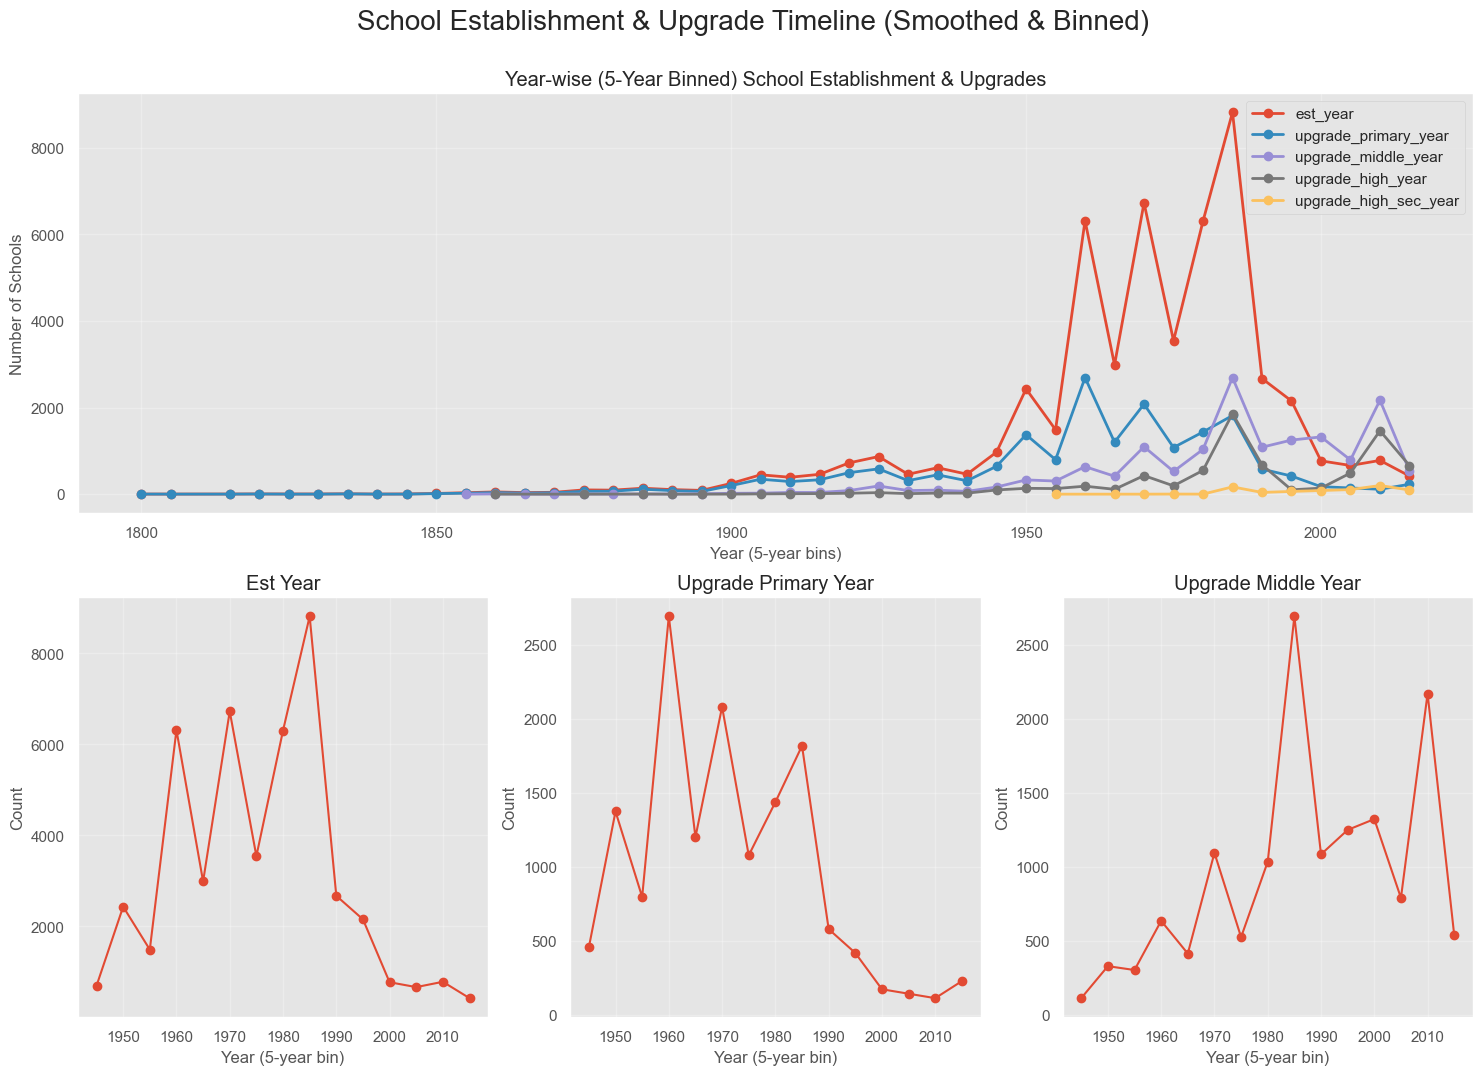

In [168]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



year_cols = [
    "est_year",
    "upgrade_primary_year",
    "upgrade_middle_year",
    "upgrade_high_year",
    "upgrade_high_sec_year"
]

# Clean year function
def clean_years(series,year):
    s = pd.to_numeric(series, errors="coerce")
    return s[(s >= year) & (s <= 2030)]

# Bin function (5-year bins)
def bin_years(series):
    return (series // 5) * 5   # 1991–1995 → 1990, 1996–2000 → 1995, etc.


# ---------------- MAIN FIGURE ----------------

plt.figure(figsize=(18, 12))
plt.suptitle("School Establishment & Upgrade Timeline (Smoothed & Binned)", fontsize=20, y=0.95)


# ---------- 1) COMBINED LINE PLOT (BINNED) ----------
plt.subplot(2, 1, 1)

for col in year_cols:
    cleaned = clean_years(df[col],year = 1700)
    if cleaned.empty:
        continue

    binned = bin_years(cleaned)
    counts = binned.value_counts().sort_index()

    plt.plot(counts.index, counts.values, marker="o", linewidth=2, label=col)

plt.title("Year-wise (5-Year Binned) School Establishment & Upgrades")
plt.xlabel("Year (5-year bins)")
plt.ylabel("Number of Schools")
plt.grid(True, alpha=0.3)
plt.legend()


# ---------- 2) SUBPLOTS (SMOOTHED COUNTS) ----------
subplot_positions = {
    "est_year": 4,
    "upgrade_primary_year": 5,
    "upgrade_middle_year": 6,
    "upgrade_high_year": 7,
    "upgrade_high_sec_year": 8
}

for col in year_cols:
    plt.subplot(2, 3, subplot_positions[col])

    cleaned = clean_years(df[col],year = 1947)

    if cleaned.empty:
        plt.text(0.5, 0.5, "No valid data", ha="center", va="center")
        plt.title(col.replace("_", " ").title())
        continue

    binned = bin_years(cleaned)
    counts = binned.value_counts().sort_index()

    # Line plot instead of bar → MUCH LESS CLUTTER
    plt.plot(counts.index, counts.values, marker="o")
    plt.title(col.replace("_", " ").title())
    plt.xlabel("Year (5-year bin)")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


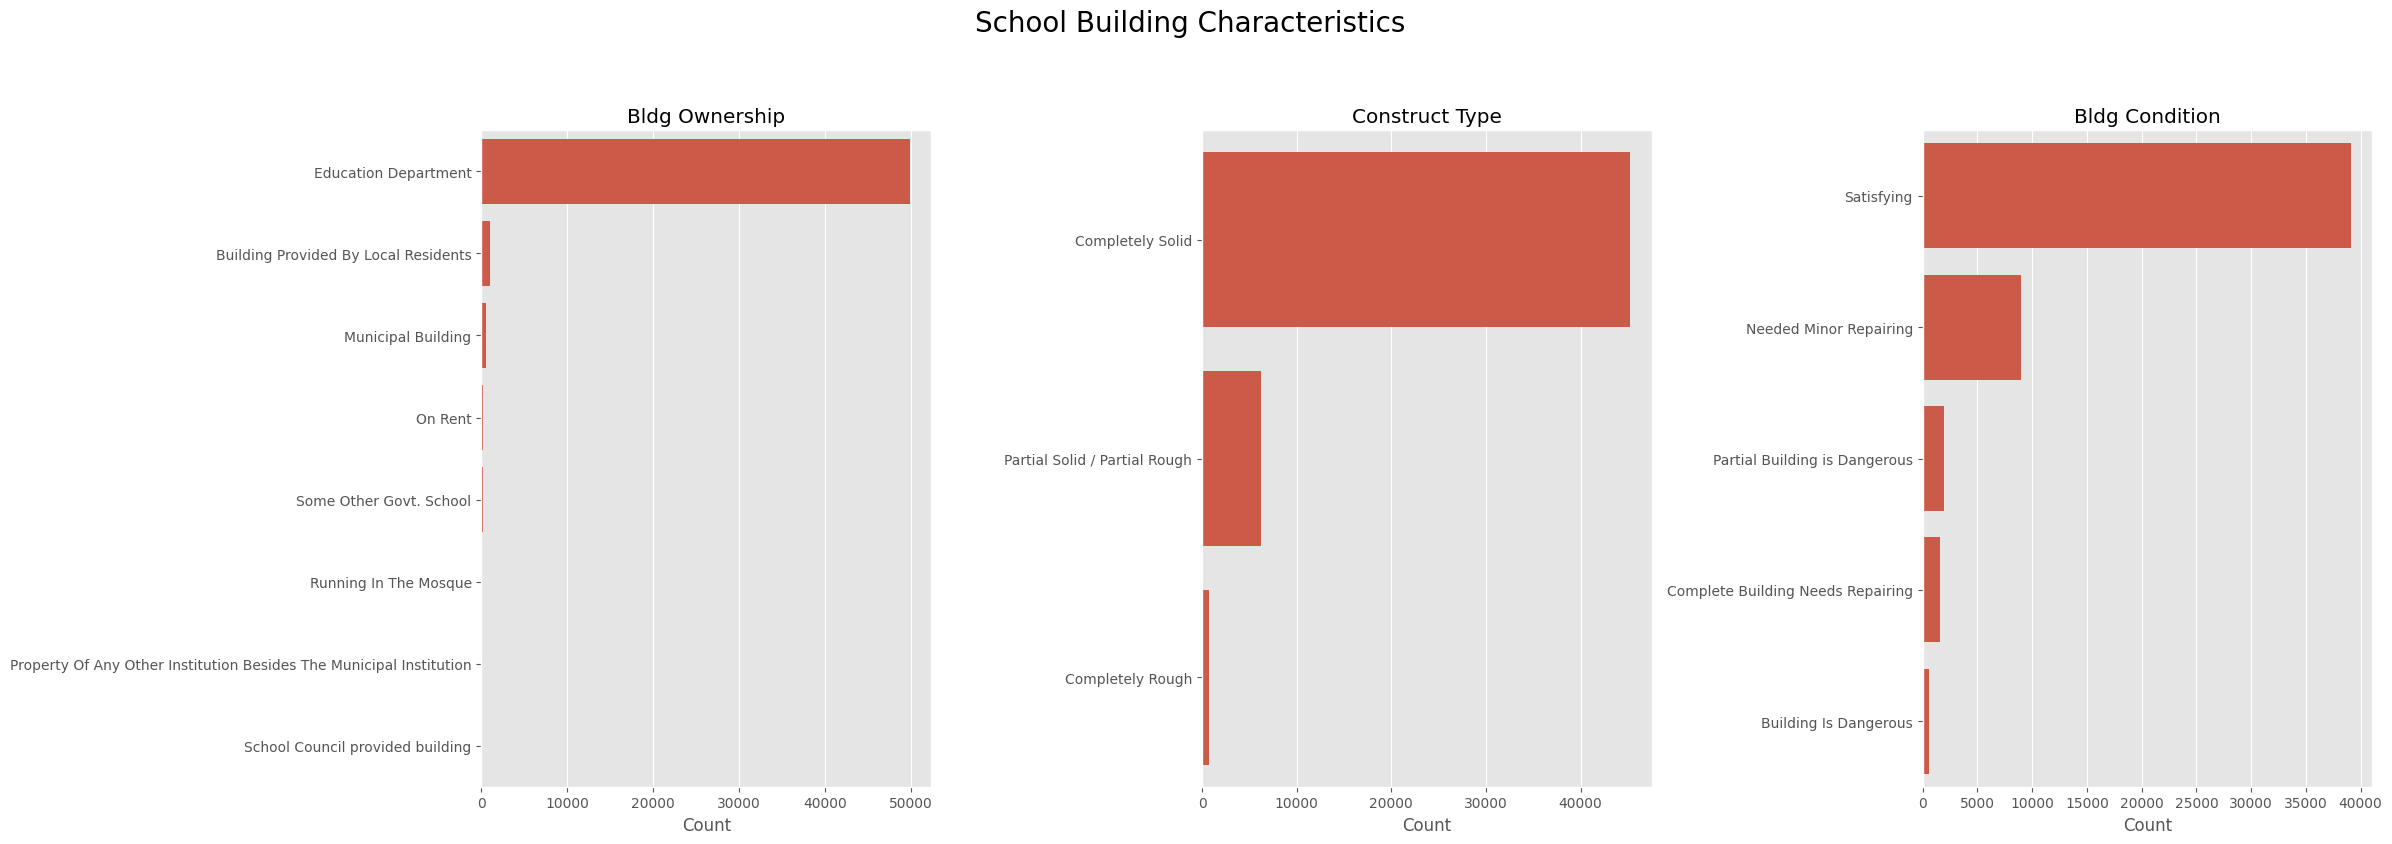

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

plt.style.use("ggplot")

# Columns to visualize
cols = ["bldg_ownership", "construct_type", "bldg_condition"]

# Remove category values 1 and 2 from these columns
for col in cols:
    df[col] = df[col].replace({"1": None, "2": None})

# Set up figure
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle("School Building Characteristics ", fontsize=20, y=1.05)

# Plot bar charts
for i, col in enumerate(cols):
    counts = df[col].value_counts()

    sns.barplot(
        x=counts.values,
        y=counts.index,
        ax=axes[i]
    )

    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()


In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Load data

# plt.style.use("ggplot")

# area_cols = [
#     "total_area_kanal",
#     "total_area_marla",
#     "covered_area",
#     "uncovered_area_kanal",
#     "uncovered_area_marla"
# ]

# # Convert to numeric + clean
# for col in area_cols:
#     df[col] = pd.to_numeric(df[col], errors="coerce")

# # Create figure
# fig, axes = plt.subplots(2, 3, figsize=(22, 12))
# fig.suptitle("School Area Metrics Distribution", fontsize=20, y=1.05)

# axes = axes.flatten()

# # Plot histograms + KDE
# for i, col in enumerate(area_cols):
#     sns.histplot(
#         df[col].dropna(),
#         kde=True,
#         ax=axes[i],
#         bins=20
#     )
#     axes[i].set_title(col.replace("_", " ").title())
#     axes[i].set_xlabel("Value")
#     axes[i].set_ylabel("Frequency")

# # Remove unused 6th panel
# fig.delaxes(axes[-1])

# plt.tight_layout()
# plt.show()


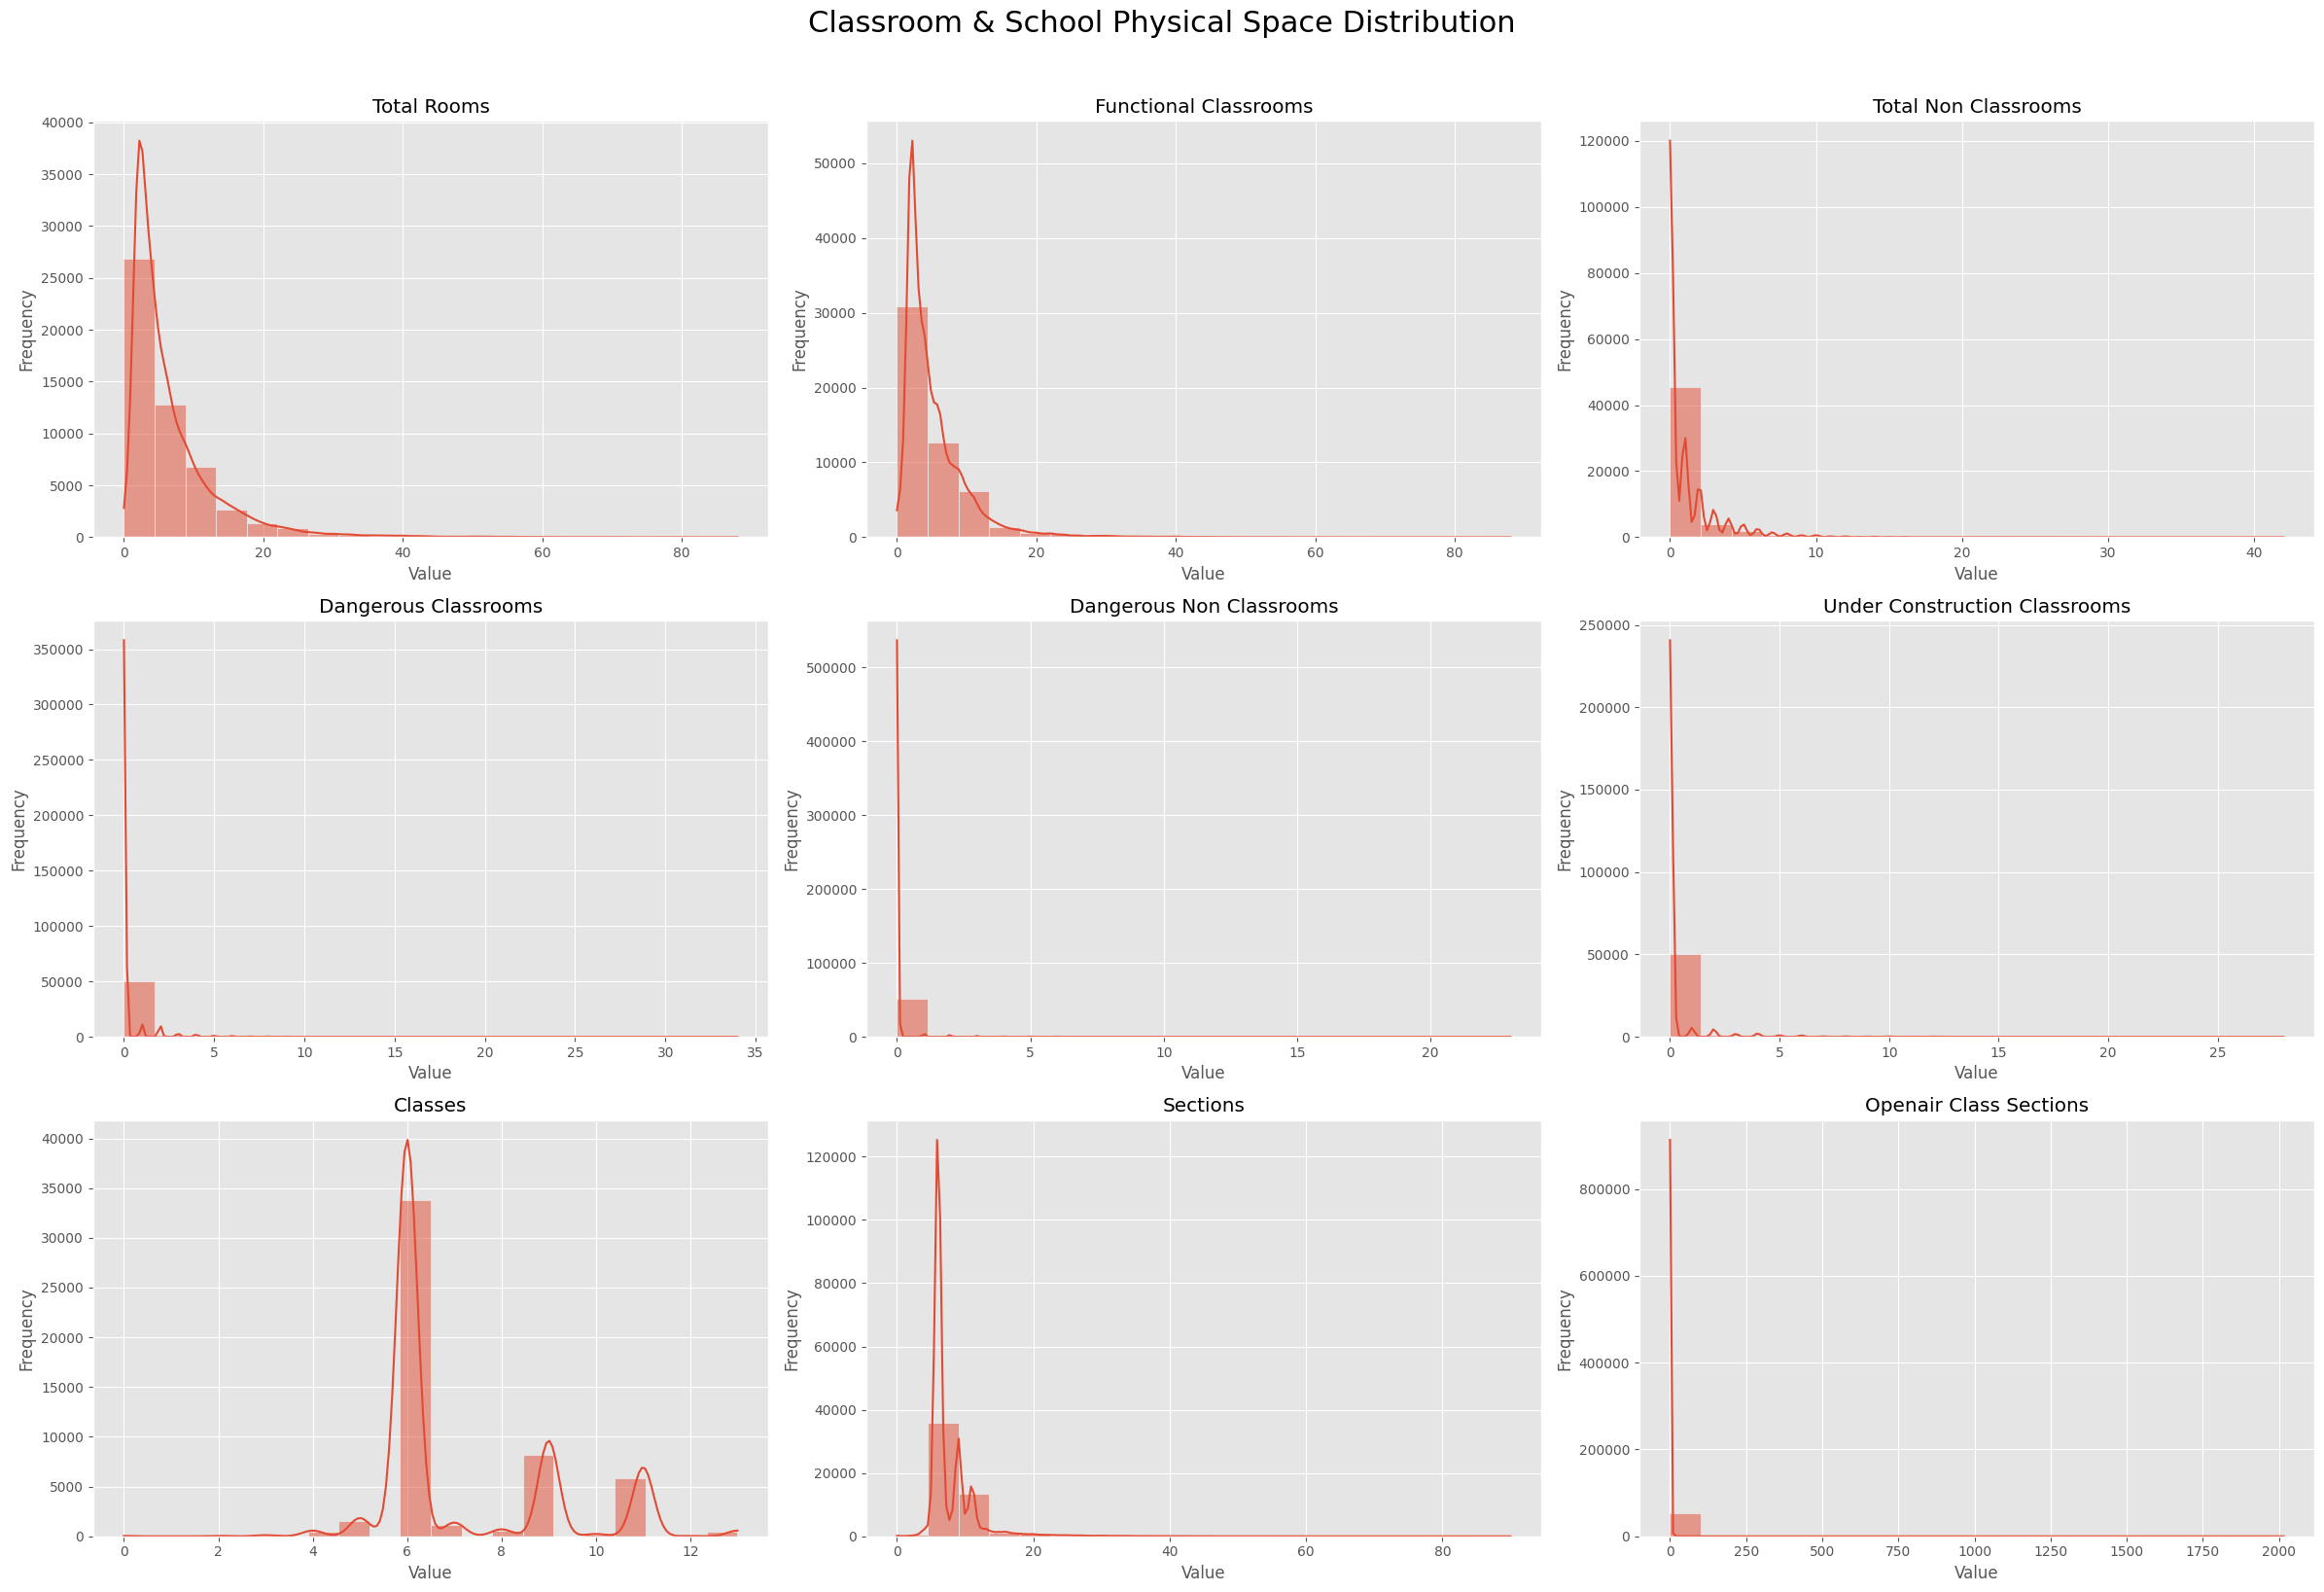

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

plt.style.use("ggplot")

class_cols = [
    "total_rooms",
    "functional_classrooms",
    "total_non_classrooms",
    "dangerous_classrooms",
    "dangerous_non_classrooms",
    "under_construction_classrooms",
    "classes",
    "sections",
    "openair_class_sections"
]

# Convert to numeric + clean
for col in class_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Create figure
fig, axes = plt.subplots(3, 3, figsize=(24, 16))
fig.suptitle("Classroom & School Physical Space Distribution", fontsize=22, y=1.02)

axes = axes.flatten()

# Plot histograms + KDE
for i, col in enumerate(class_cols):
    sns.histplot(
        df[col].dropna(),
        kde=True,
        ax=axes[i],
        bins=20
    )
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


/var/folders/0x/rx6z5n5d6dzbfbmmrfbxwsdw0000gn/T/ipykernel_79098/2416125450.py:5: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/robbannn/Desktop/SEM_5/DV_PROJECT/public-census_oct_2018.csv")


drink_water
1    52197
0      267
Name: count, dtype: int64
drink_water
1    52197
0      267
Name: count, dtype: int64


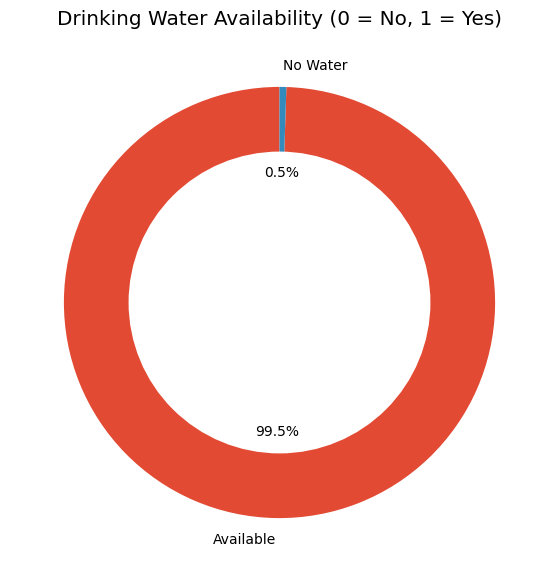

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/robbannn/Desktop/SEM_5/DV_PROJECT/public-census_oct_2018.csv")

# ---------------- CLEANING ----------------

# Convert to numeric
df["drink_water"] = pd.to_numeric(df["drink_water"], errors="coerce")
df["drink_water_type"] = pd.to_numeric(df["drink_water_type"], errors="coerce")
df["drink_water_type_other"] = pd.to_numeric(df["drink_water_type_other"], errors="coerce")

# Remove invalid values
df = df[df["drink_water"] != 2]                     # Keep only 0 and 1
df = df[df["drink_water_type"] != "3"]               # Remove invalid
df = df[df["drink_water_type_other"] != "3"]         # Remove invalid
print(df["drink_water"].value_counts())
plt.style.use("ggplot")


# ---------------- VISUAL 1: Donut Chart for Availability ----------------

avail_counts = df["drink_water"].value_counts()  # contains 0 and 1
print(avail_counts)

plt.figure(figsize=(7, 7))
plt.pie(avail_counts,
        labels=["No Water" if x == 0 else "Available" for x in avail_counts.index],
        autopct="%1.1f%%",
        startangle=90)

# Donut hole
circle = plt.Circle((0, 0), 0.70, fc="white")
plt.gca().add_artist(circle)

plt.title("Drinking Water Availability (0 = No, 1 = Yes)")
plt.show()




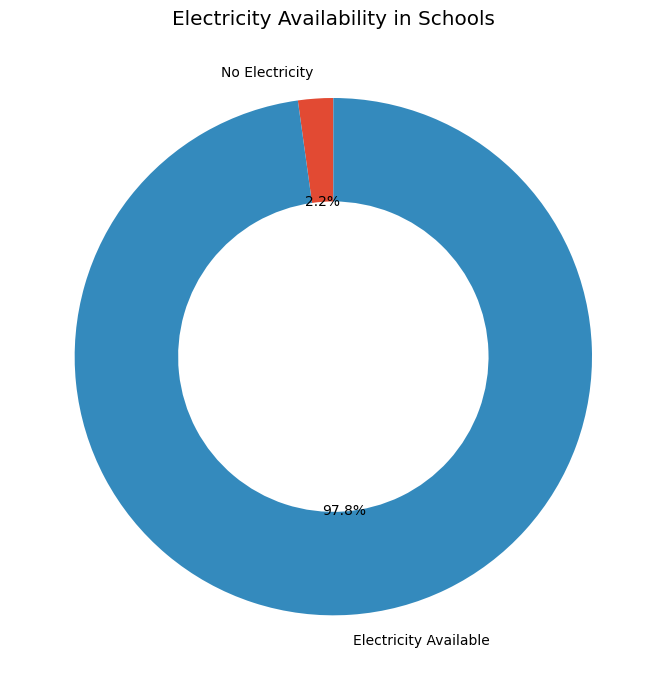

In [ ]:
import matplotlib.pyplot as plt

# Keep only 0 and 1
df_elec = df[df["electricity"].isin([0,1])]

electricity_counts = df_elec["electricity"].value_counts().sort_index()

plt.figure(figsize=(7,7))

# Donut chart
plt.pie(
    electricity_counts,
    labels=["No Electricity", "Electricity Available"],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Electricity Availability in Schools")
plt.tight_layout()
plt.show()


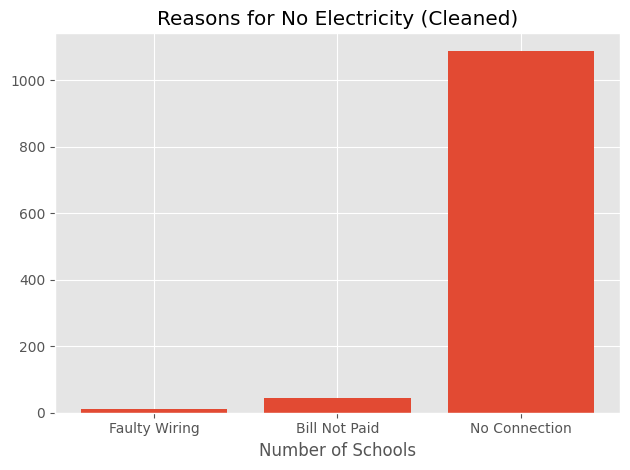

In [ ]:
# Filter only non-electric schools
df_no_elec = df[df["electricity"] == 0]

# Remove invalid codes (example: keep only text reasons)
df_no_elec_clean = df_no_elec[
    (df_no_elec["no_electricity_reason"].notna()) &
    (df_no_elec["no_electricity_reason"].astype(str).str.strip() != "") &
    (~df_no_elec["no_electricity_reason"].isin(["1","2","3"]))
]

reason_counts = df_no_elec_clean["no_electricity_reason"].value_counts().sort_values()


plt.bar(reason_counts.index, reason_counts.values)
plt.xlabel("Number of Schools")
plt.title("Reasons for No Electricity (Cleaned)")
plt.tight_layout()
plt.show()


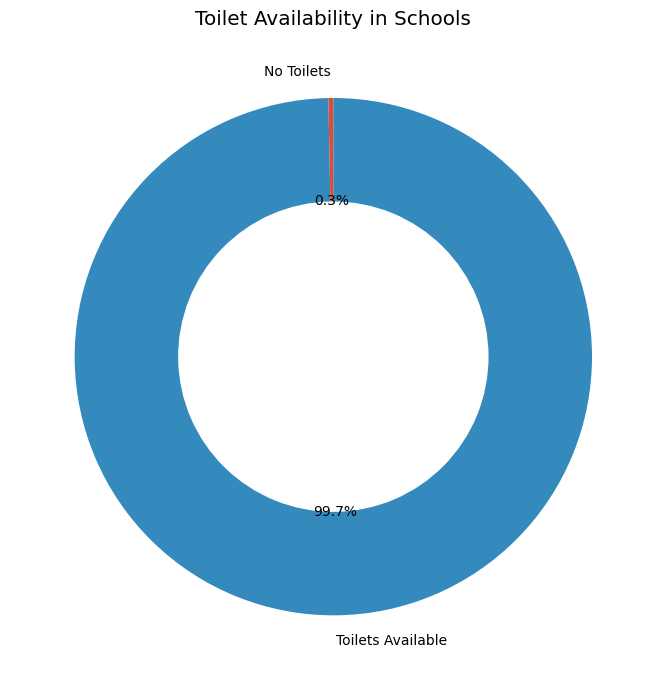

In [ ]:
import matplotlib.pyplot as plt

# Keep only 0/1
df_t = df[df["toilets"].isin([0,1])]

toilet_avail = df_t["toilets"].value_counts().sort_index()

plt.figure(figsize=(7,7))
plt.pie(
    toilet_avail,
    labels=["No Toilets", "Toilets Available"],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)
plt.title("Toilet Availability in Schools")
plt.tight_layout()
plt.show()


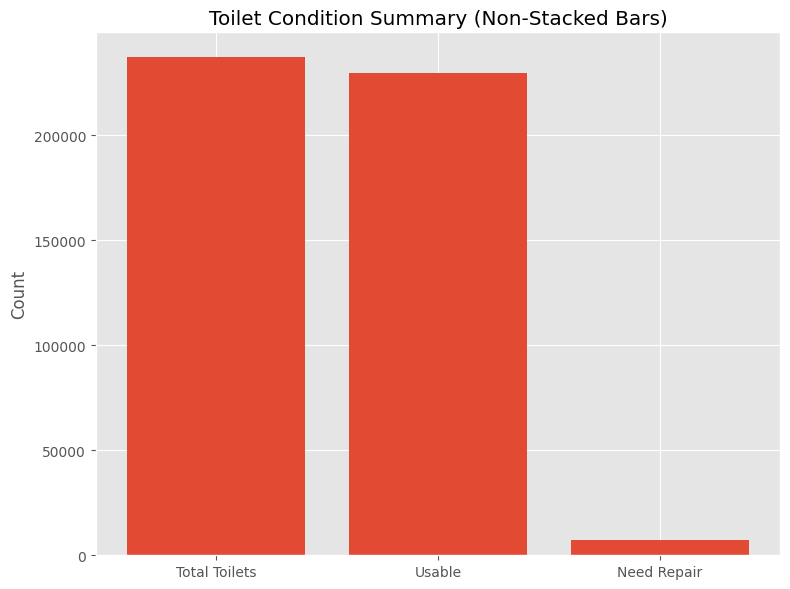

In [ ]:
import matplotlib.pyplot as plt

# Totals
total = df["total_toilets"].sum()
usable = df["usable_toilets"].sum()
repair = df["need_repairing_toilets"].sum()

categories = ["Total Toilets", "Usable", "Need Repair"]
values = [total, usable, repair]

plt.figure(figsize=(8,6))
plt.bar(categories, values)

plt.ylabel("Count")
plt.title("Toilet Condition Summary (Non-Stacked Bars)")
plt.tight_layout()
plt.show()


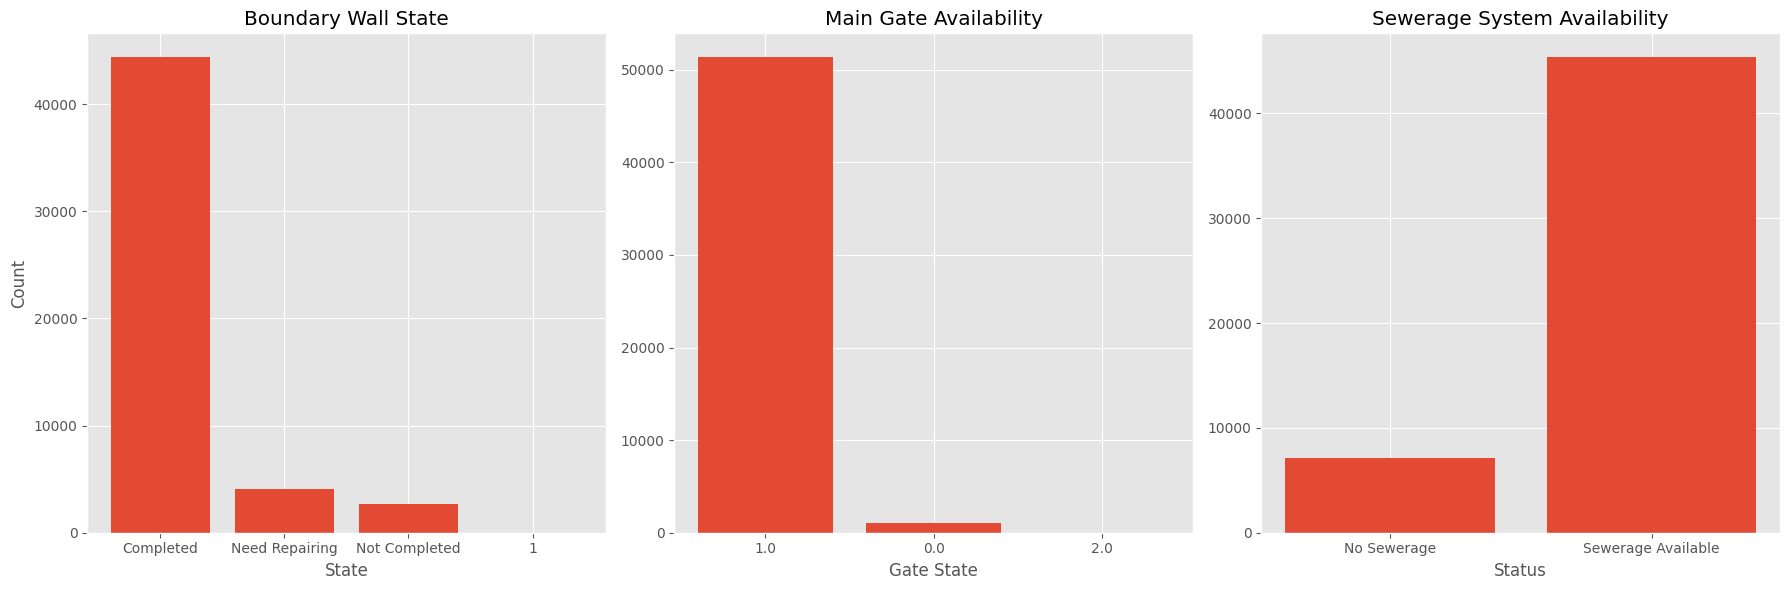

In [ ]:
import matplotlib.pyplot as plt

# Clean sewerage: keep only 0/1
df_sw = df[df["sewerage"].isin([0,1])]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- 1. Boundary Wall State ---
bw_counts = df["boundary_wall_state"].value_counts()
axes[0].bar(bw_counts.index.astype(str), bw_counts.values)
axes[0].set_title("Boundary Wall State")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Count")

# --- 2. Main Gate ---
mg_counts = df["main_gate"].value_counts()
axes[1].bar(mg_counts.index.astype(str), mg_counts.values)
axes[1].set_title("Main Gate Availability")
axes[1].set_xlabel("Gate State")

# --- 3. Sewerage (Only 0 and 1) ---
sw_counts = df_sw["sewerage"].value_counts().sort_index()
axes[2].bar(["No Sewerage", "Sewerage Available"], sw_counts.values)
axes[2].set_title("Sewerage System Availability")
axes[2].set_xlabel("Status")

plt.tight_layout()
plt.show()



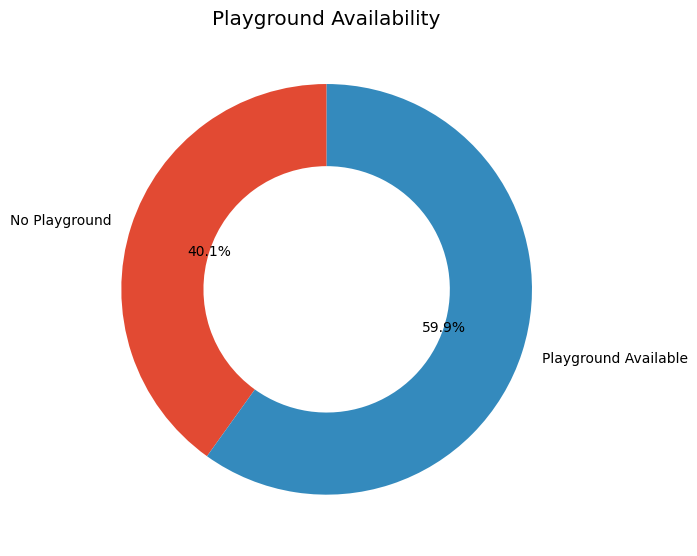

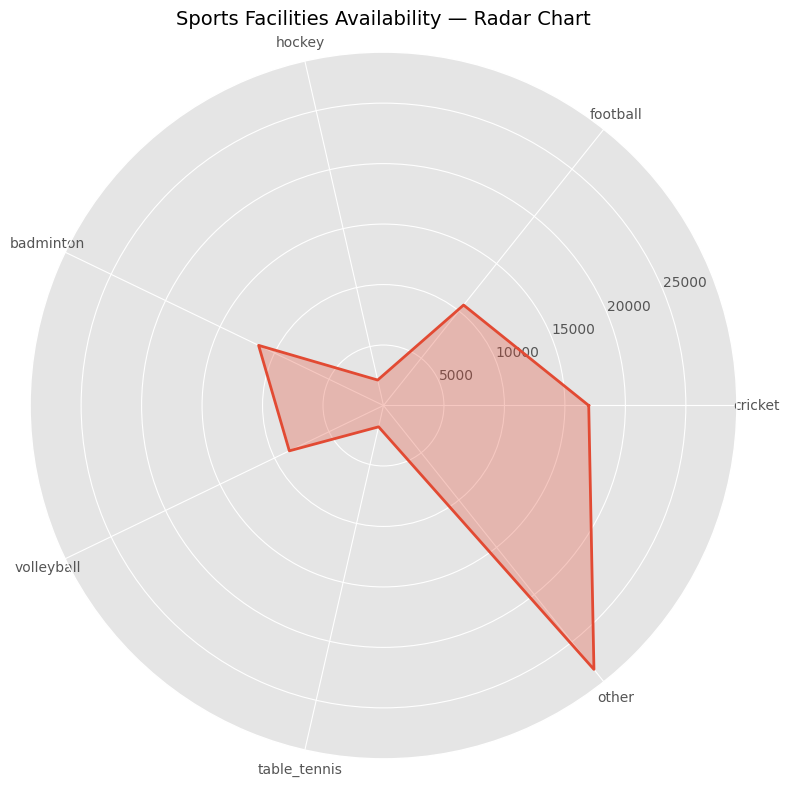

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------------------------------
# CLEANING — Convert to numeric and handle only 0/1
# -----------------------------------------------------

sports_cols = [
    "cricket", "football", "hockey", "badminton",
    "volleyball", "table_tennis", "other"
]

# Convert to int (some may be strings)
for col in sports_cols + ["play_ground"]:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)


# -----------------------------------------------------
# 3️⃣ DONUT CHART — PLAYGROUND AVAILABILITY
# -----------------------------------------------------

pg_counts = df["play_ground"].replace(2, 1).value_counts().sort_index()
plt.figure(figsize=(7,7))
plt.pie(
    pg_counts,
    labels=["No Playground", "Playground Available"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)
plt.title("Playground Availability")
plt.tight_layout()
plt.show()


# -----------------------------------------------------
# 1️⃣ RADAR CHART — COMPLEX VISUAL FOR ALL SPORTS
# -----------------------------------------------------

sports_sum = df[sports_cols].sum()

labels = sports_sum.index
values = sports_sum.values

# Close the circle
values = np.append(values, values[0])
angles = np.linspace(0, 2 * np.pi, len(values))

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

ax.plot(angles, values, linewidth=2)
ax.fill(angles, values, alpha=0.3)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_title("Sports Facilities Availability — Radar Chart", size=14, pad=20)

plt.tight_layout()
plt.show()



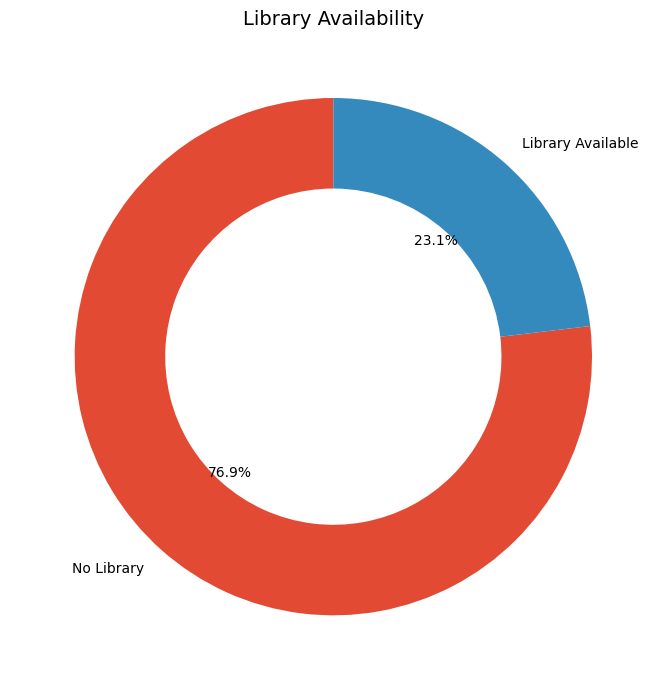

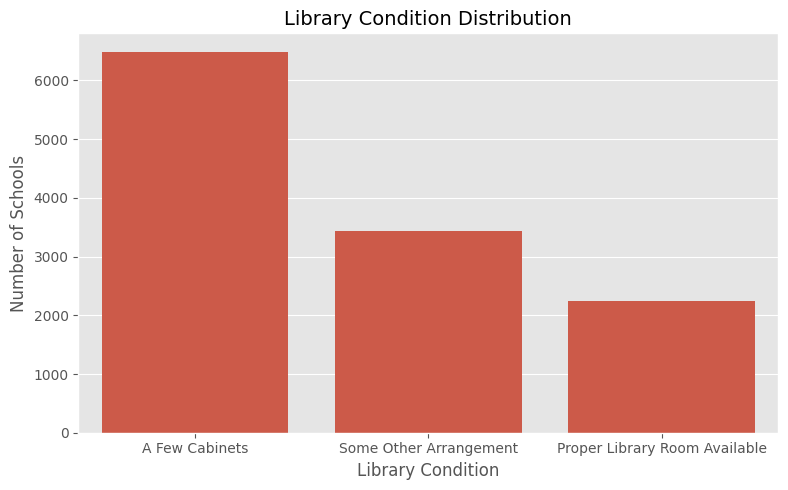

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# CLEAN DATA
# -------------------------------

# Convert to numeric (if needed)
df["library"] = pd.to_numeric(df["library"], errors="coerce").replace(2,1).fillna(0).astype(int)
df["total_books"] = pd.to_numeric(df["total_books"], errors="coerce").fillna(0)

# Clean library_condition: remove codes 0/1/2/3 if they exist
df["library_condition"] = df["library_condition"].replace({
    0: None, 1: None, 2: None, 3: None
})

# -------------------------------
# 1️⃣ DONUT CHART — LIBRARY AVAILABLE OR NOT
# -------------------------------
lib_counts = df["library"].value_counts().sort_index()

plt.figure(figsize=(7,7))
plt.pie(
    lib_counts,
    labels=["No Library", "Library Available"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.35}
)
plt.title("Library Availability", fontsize=14)
plt.tight_layout()
plt.show()

# -------------------------------
# 2️⃣ BAR CHART — LIBRARY CONDITION
# -------------------------------

condition_counts = df["library_condition"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(
    x=condition_counts.index,
    y=condition_counts.values
)
plt.title("Library Condition Distribution", fontsize=14)
plt.xlabel("Library Condition")
plt.ylabel("Number of Schools")
plt.tight_layout()
plt.show()




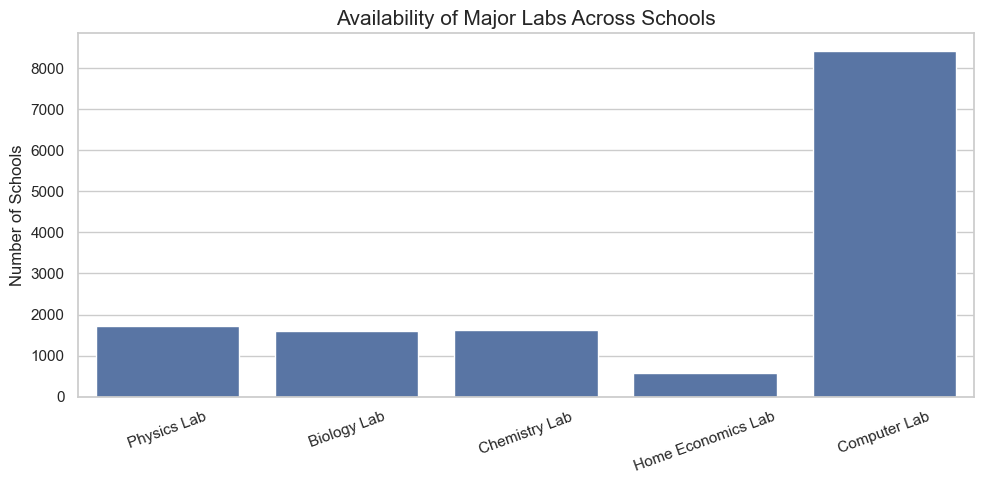

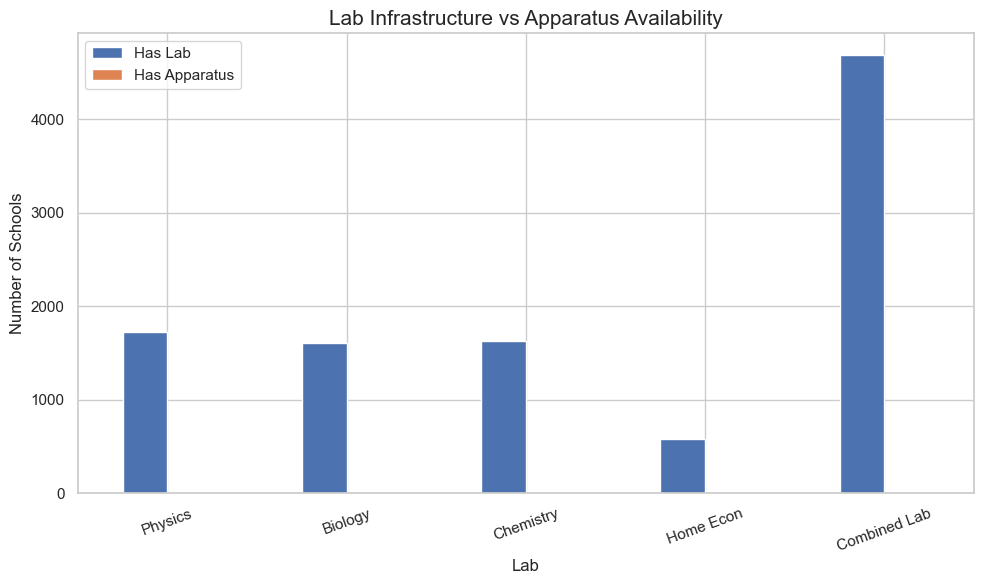

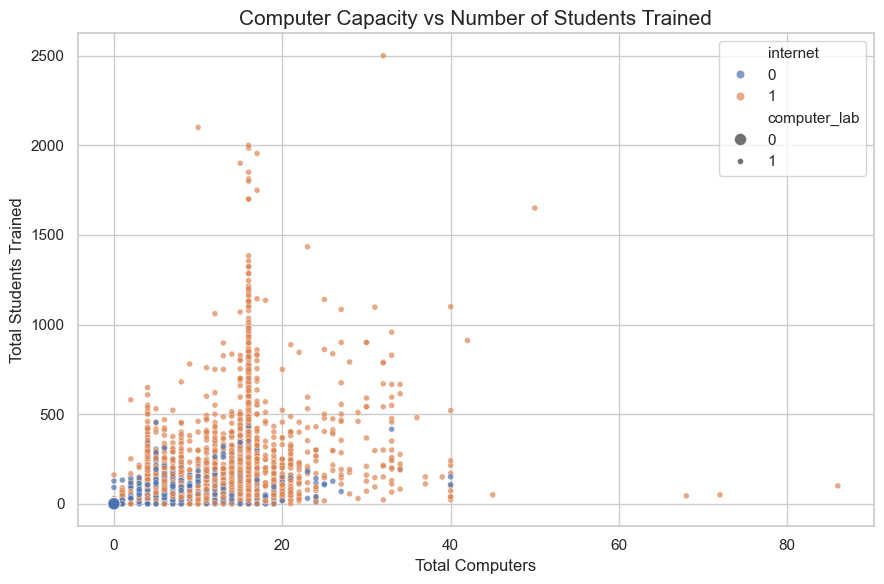

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------
# CLEANUP
# --------------------------

# Convert numeric columns
cols = [
    "science_lab","physics_lab","physics_appratus","biology_lab","biology_appratus",
    "chemistry_lab","chemistry_appratus","home_economic_lab","home_economic_appratus",
    "combine_lab","combine_appratus","computer_lab","total_computers",
    "total_computer_training_students","internet"
]

df[cols] = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)


# --------------------------
# 2️⃣ LAB AVAILABILITY BAR (PHYSICS, BIO, CHEM, HOME-ECO, COMPUTER)
# --------------------------
lab_features = {
    "Physics Lab": "physics_lab",
    "Biology Lab": "biology_lab",
    "Chemistry Lab": "chemistry_lab",
    "Home Economics Lab": "home_economic_lab",
    "Computer Lab": "computer_lab"
}

lab_avail = {k: df[v].sum() for k,v in lab_features.items()}

plt.figure(figsize=(10,5))
sns.barplot(x=list(lab_avail.keys()), y=list(lab_avail.values()))
plt.title("Availability of Major Labs Across Schools", fontsize=15)
plt.ylabel("Number of Schools")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# --------------------------
# 3️⃣ APPARATUS ADEQUACY COMPARISON
# physics_lab vs physics_appratus, etc
# --------------------------
apparatus_pairs = {
    "Physics": ("physics_lab", "physics_appratus"),
    "Biology": ("biology_lab", "biology_appratus"),
    "Chemistry": ("chemistry_lab", "chemistry_appratus"),
    "Home Econ": ("home_economic_lab", "home_economic_appratus"),
    "Combined Lab": ("combine_lab", "combine_appratus"),
}

adequacy_df = pd.DataFrame({
    "Lab": list(apparatus_pairs.keys()),
    "Has Lab": [df[p[0]].sum() for p in apparatus_pairs.values()],
    "Has Apparatus": [df[p[1]].sum() for p in apparatus_pairs.values()]
})

adequacy_df.set_index("Lab").plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Lab Infrastructure vs Apparatus Availability", fontsize=15)
plt.ylabel("Number of Schools")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# --------------------------
# 4️⃣ SCATTER — COMPUTERS vs TRAINED STUDENTS
# --------------------------
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x="total_computers",
    y="total_computer_training_students",
    hue="internet",
    size="computer_lab",
    alpha=0.7
)
plt.title("Computer Capacity vs Number of Students Trained", fontsize=15)
plt.xlabel("Total Computers")
plt.ylabel("Total Students Trained")
plt.tight_layout()
plt.show()


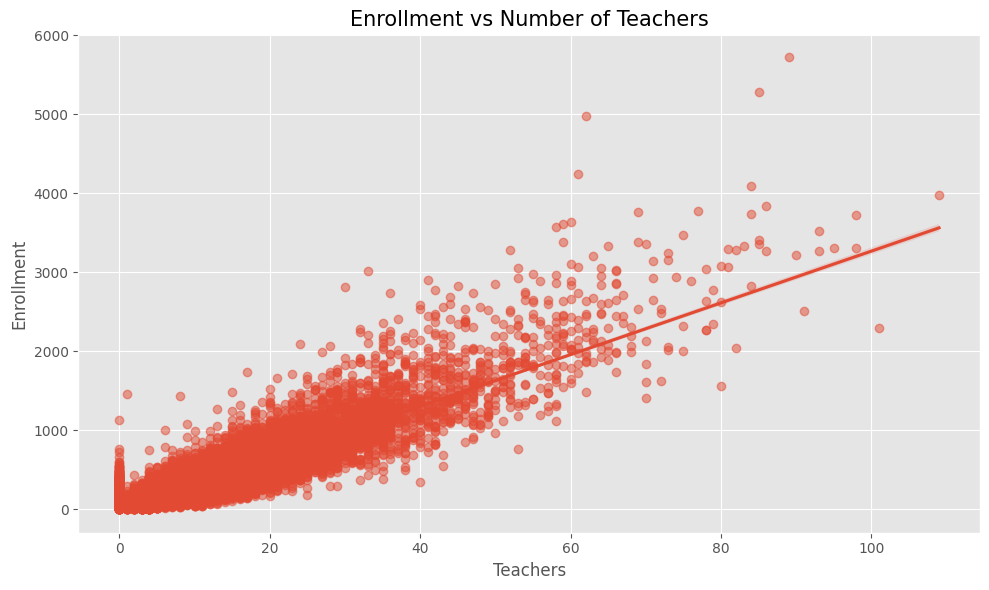

/var/folders/0x/rx6z5n5d6dzbfbmmrfbxwsdw0000gn/T/ipykernel_79098/4279238040.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby("enrollment_group")[["Teachers", "NonTeachers"]].mean().reset_index()


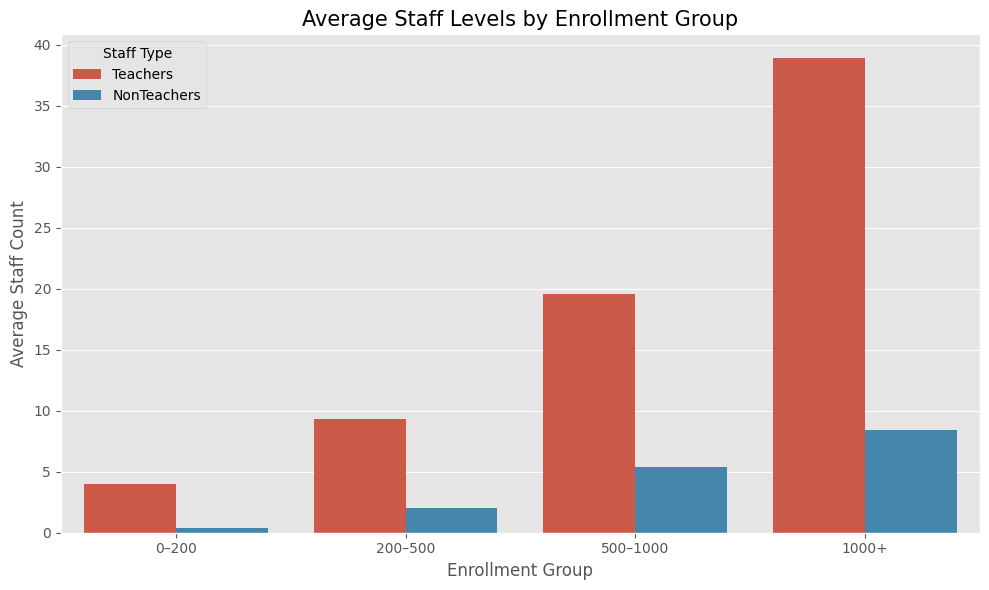

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert columns to numeric (if needed)
df["enrollment"] = pd.to_numeric(df["enrollment"], errors="coerce").fillna(0)
df["Teachers"] = pd.to_numeric(df["Teachers"], errors="coerce").fillna(0)
df["NonTeachers"] = pd.to_numeric(df["NonTeachers"], errors="coerce").fillna(0)


# ------------------------------
# 2️⃣ Enrollment vs Teachers Scatter (with regression line)
# ------------------------------
plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x="Teachers",
    y="enrollment",
    scatter_kws={"alpha":0.5}
)
plt.title("Enrollment vs Number of Teachers", fontsize=15)
plt.xlabel("Teachers")
plt.ylabel("Enrollment")
plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert
df["enrollment"] = pd.to_numeric(df["enrollment"], errors="coerce").fillna(0)
df["Teachers"] = pd.to_numeric(df["Teachers"], errors="coerce").fillna(0)
df["NonTeachers"] = pd.to_numeric(df["NonTeachers"], errors="coerce").fillna(0)

# ------------------------
# Create enrollment bins
# ------------------------
df["enrollment_group"] = pd.cut(
    df["enrollment"],
    bins=[0, 200, 500, 1000, 5000],
    labels=["0–200", "200–500", "500–1000", "1000+"]
)

# Calculate group averages
group_stats = df.groupby("enrollment_group")[["Teachers", "NonTeachers"]].mean().reset_index()

# ------------------------
# Plot
# ------------------------
plt.figure(figsize=(10,6))

group_stats_melt = group_stats.melt(id_vars="enrollment_group", var_name="Staff Type", value_name="Average Count")

sns.barplot(
    data=group_stats_melt,
    x="enrollment_group",
    y="Average Count",
    hue="Staff Type"
)

plt.title("Average Staff Levels by Enrollment Group", fontsize=15)
plt.xlabel("Enrollment Group")
plt.ylabel("Average Staff Count")
plt.legend(title="Staff Type")
plt.tight_layout()
plt.show()



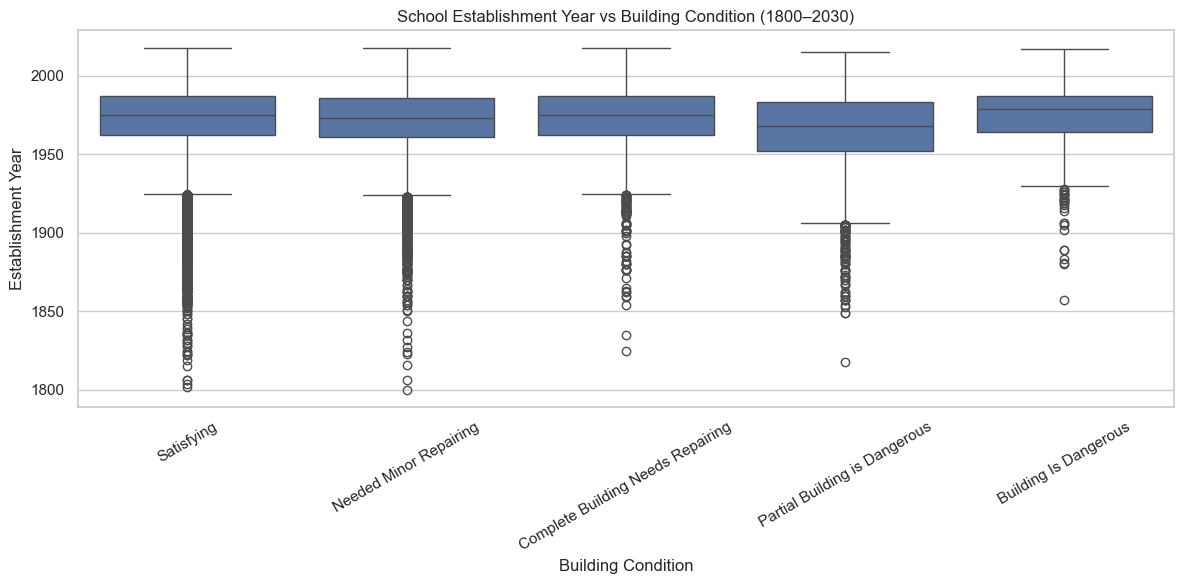

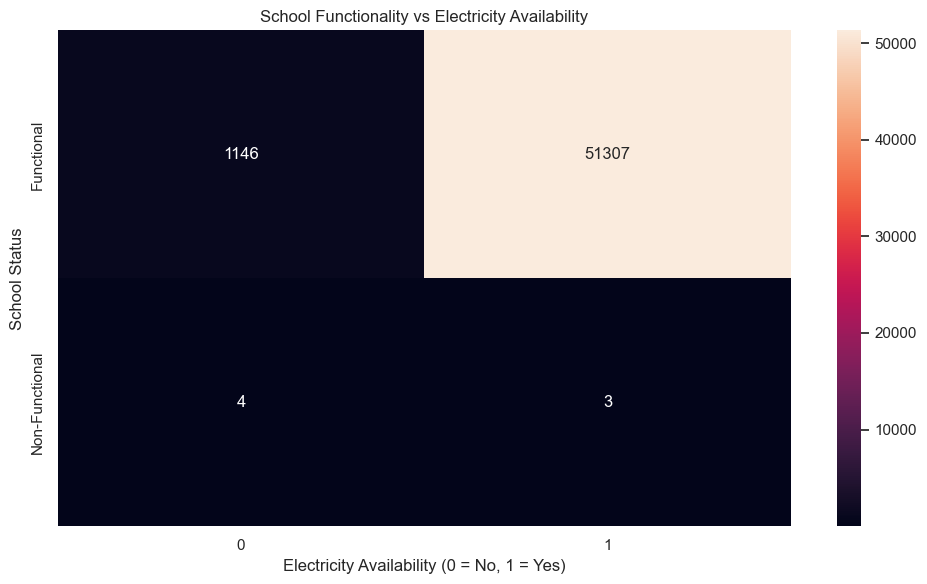

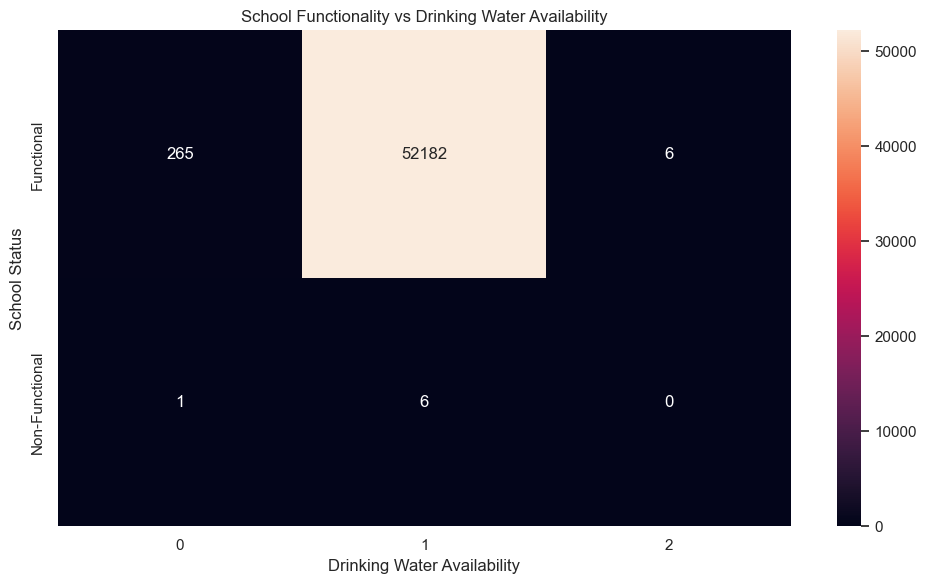

/var/folders/0x/rx6z5n5d6dzbfbmmrfbxwsdw0000gn/T/ipykernel_79098/2217743228.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ts_ratio"].replace([float("inf"), -float("inf")], None, inplace=True)


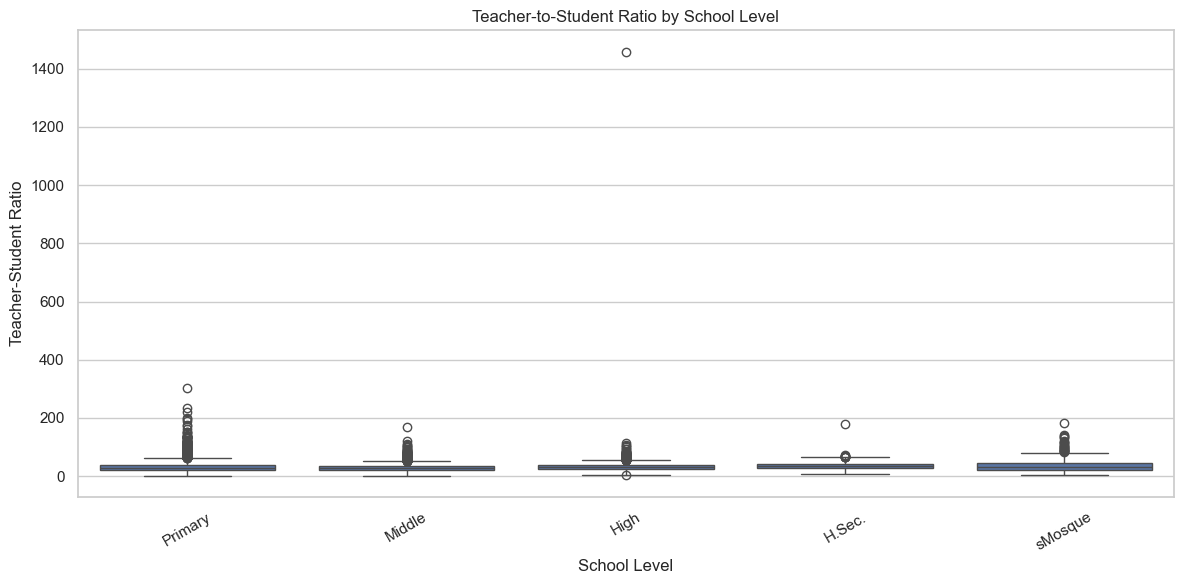

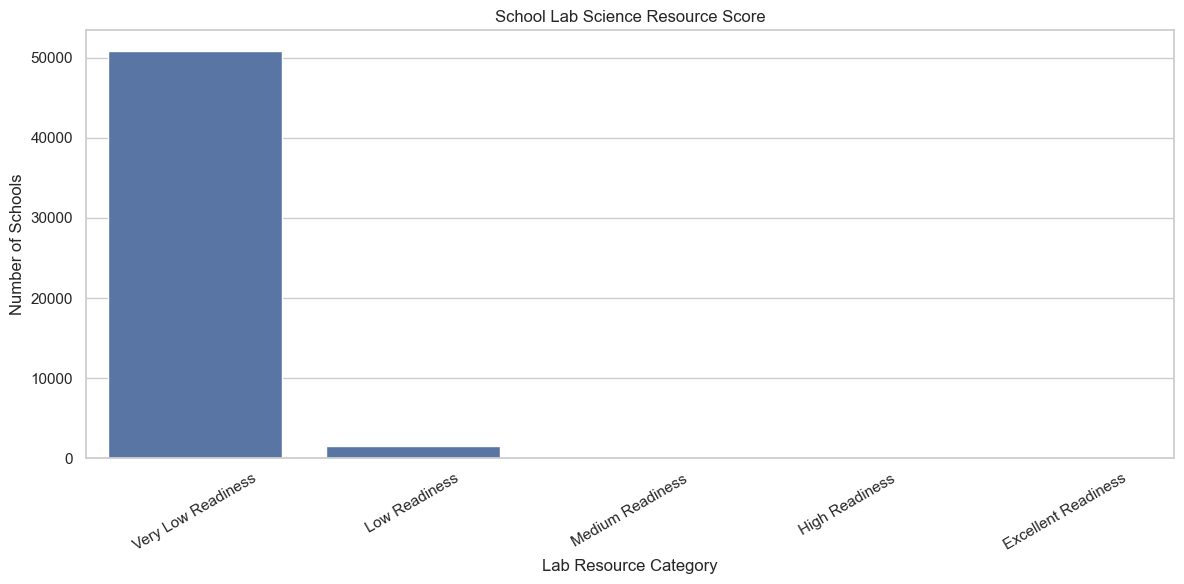

In [179]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------
# 0) Ensure clean theme
# ---------------------------------------------------
sns.set(style="whitegrid")

# ---------------------------------------------------
# 1) School Establishment Year vs Building Condition
# ---------------------------------------------------
# Filter unrealistic years
df = df[(df["est_year"] >= 1800) & (df["est_year"] <= 2030)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="bldg_condition", y="est_year")
plt.title("School Establishment Year vs Building Condition (1800–2030)")
plt.xlabel("Building Condition")
plt.ylabel("Establishment Year")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 2) School Functionality vs Utilities (Electricity, Drinking Water)
# ---------------------------------------------------
df = df[df["electricity"].isin([0, 1])]
# Electricity
plt.figure(figsize=(10,6))

sns.heatmap(
    pd.crosstab(df["school_status"], df["electricity"]),
    annot=True, fmt="d"
)
plt.title("School Functionality vs Electricity Availability")
plt.xlabel("Electricity Availability (0 = No, 1 = Yes)")
plt.ylabel("School Status")
plt.tight_layout()
plt.show()

# Drinking Water
plt.figure(figsize=(10,6))
sns.heatmap(
    pd.crosstab(df["school_status"], df["drink_water"]),
    annot=True, fmt="d"
)
plt.title("School Functionality vs Drinking Water Availability")
plt.xlabel("Drinking Water Availability")
plt.ylabel("School Status")
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 3) Teacher-to-Student Ratio by School Level
# ---------------------------------------------------

df["ts_ratio"] = df["enrollment"] / df["Teachers"]
df["ts_ratio"].replace([float("inf"), -float("inf")], None, inplace=True)

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="school_level", y="ts_ratio")
plt.title("Teacher-to-Student Ratio by School Level")
plt.xlabel("School Level")
plt.ylabel("Teacher-Student Ratio")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 4) Sports Facilities Count vs Enrollment
# ---------------------------------------------------

# sports_cols = ["cricket","football","hockey","badminton","volleyball","table_tennis","other"]
# df["sports_count"] = df[sports_cols].sum(axis=1)

# plt.figure(figsize=(10,6))
# sns.scatterplot(data=df, x="sports_count", y="enrollment")
# plt.title("Sports Facilities Count vs Enrollment")
# plt.xlabel("Number of Sports Facilities")
# plt.ylabel("Enrollment")
# plt.tight_layout()
# plt.show()

# ---------------------------------------------------
# 5) Lab Readiness Distribution (Combined Lab Score)
# ---------------------------------------------------

# ---------------------------------------------------
# LAB READINESS – Clear Labeled Categories
# ---------------------------------------------------

# ---------------------------------------------------
# 5) LAB READINESS – SAFE FIXED VERSION
# ---------------------------------------------------

lab_cols = [
    "physics_lab","physics_appratus",
    "biology_lab","biology_appratus",
    "chemistry_lab","chemistry_appratus",
    "home_economic_lab","home_economic_appratus",
    "combine_lab","combine_appratus",
    "computer_lab"
]

# 1) Ensure all missing columns exist
for col in lab_cols:
    if col not in df.columns:
        df[col] = 0

# 2) Force columns to numeric (strings → NaN → 0)
df[lab_cols] = df[lab_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# 3) Now safe to sum
df["lab_score"] = df[lab_cols].sum(axis=1)

# 4) Readiness label
def label_readiness(score):
    if score <= 3:
        return "Very Low Readiness"
    elif score <= 7:
        return "Low Readiness"
    elif score <= 11:
        return "Medium Readiness"
    elif score <= 15:
        return "High Readiness"
    else:
        return "Excellent Readiness"

df["lab_readiness_label"] = df["lab_score"].apply(label_readiness)

# 5) Plot
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x="lab_readiness_label",
    order=[
        "Very Low Readiness",
        "Low Readiness",
        "Medium Readiness",
        "High Readiness",
        "Excellent Readiness"
    ]
)
plt.title("School Lab Science Resource Score")
plt.xlabel("Lab Resource Category")
plt.ylabel("Number of Schools")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


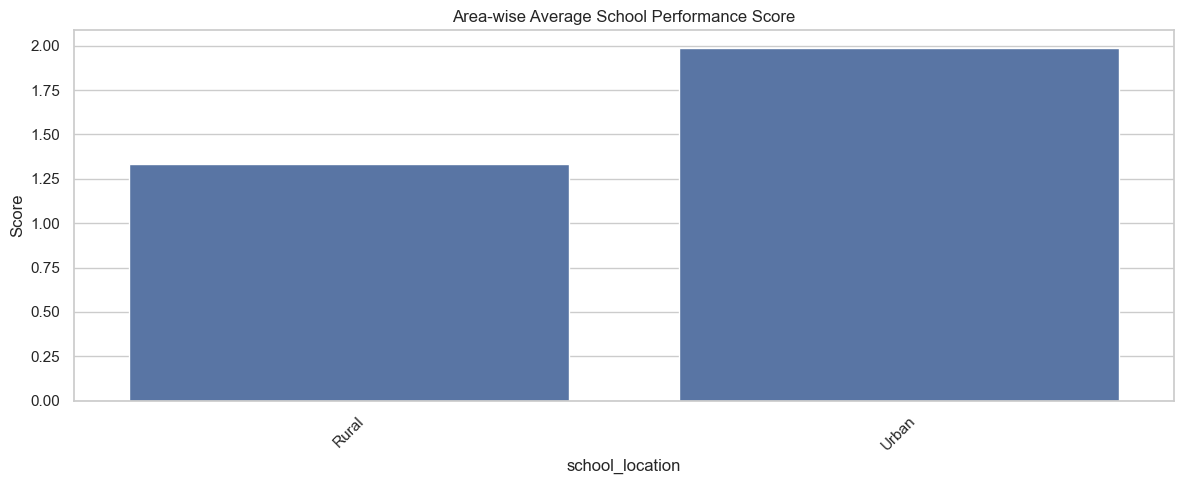

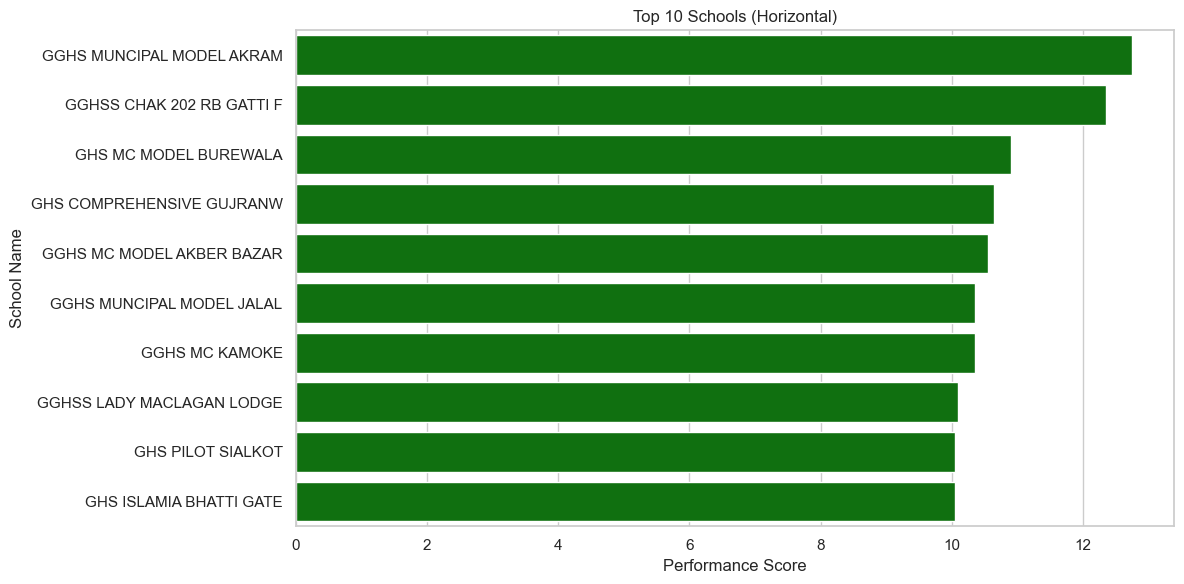

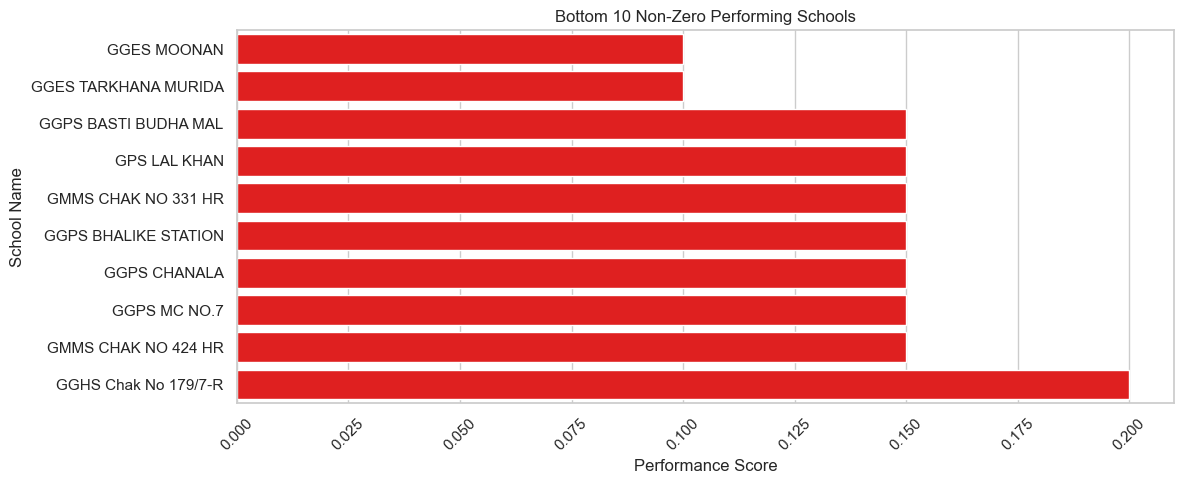

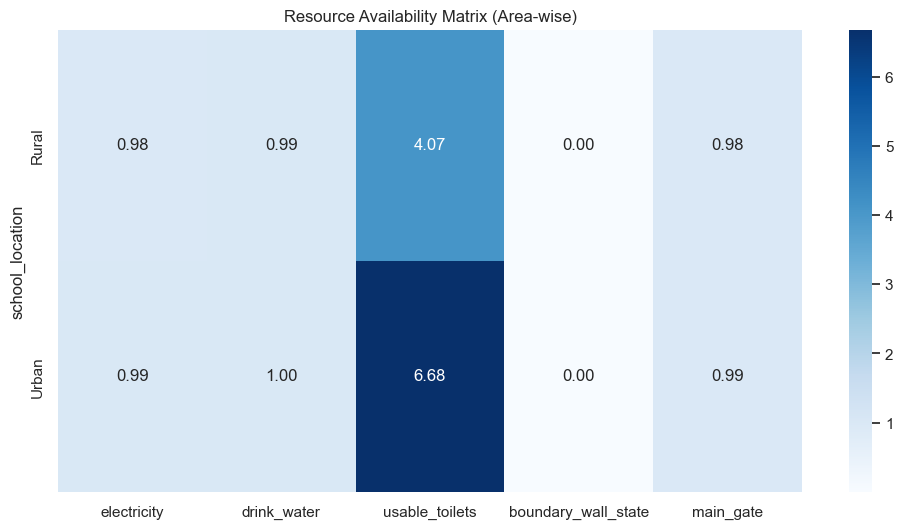

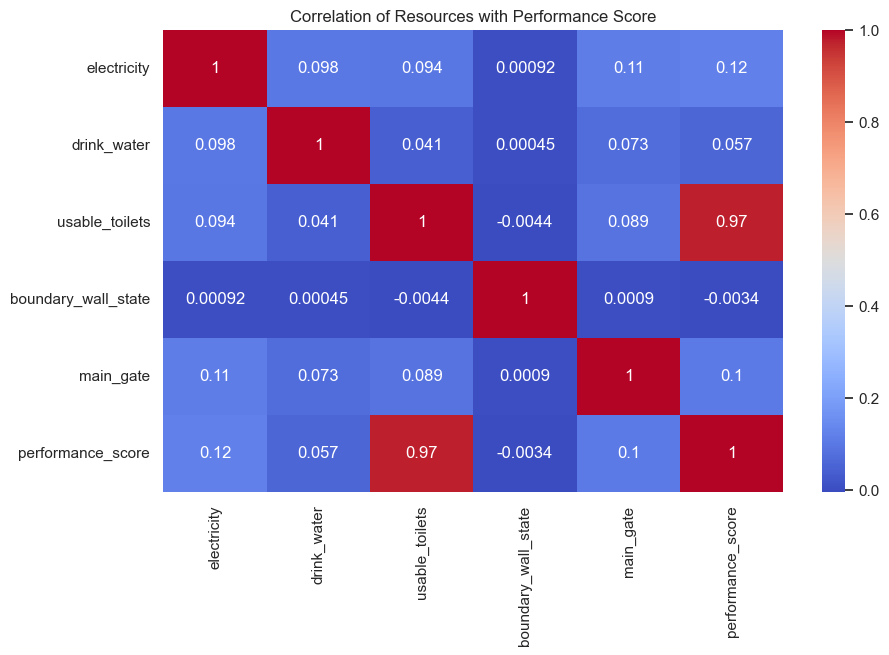

In [185]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 0. LAB COLUMNS
# --------------------------------------------------------------
lab_cols = [
    "physics_lab","physics_appratus",
    "biology_lab","biology_appratus",
    "chemistry_lab","chemistry_appratus",
    "home_economic_lab","home_economic_appratus",
    "combine_lab","combine_appratus",
    "computer_lab"
]

# Ensure all lab columns exist and are numeric
for col in lab_cols:
    if col not in df.columns:
        df[col] = 0
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df["lab_score"] = df[lab_cols].sum(axis=1)

# --------------------------------------------------------------
# 1. RESOURCE COLUMNS
# --------------------------------------------------------------
resource_cols = [
    "electricity", "drink_water", "usable_toilets",
    "boundary_wall_state", "main_gate"
]

for col in resource_cols:
    if col not in df.columns:
        df[col] = 0
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# ⚠ FIX: Do NOT replace with NaN (this caused all-zero scores!)
df["electricity"] = df["electricity"].replace({2: 0})
df["drink_water"] = df["drink_water"].replace({2: 0})
df["boundary_wall_state"] = df["boundary_wall_state"].replace({2: 0, 3: 0})
df["main_gate"] = df["main_gate"].replace({2: 0, 3: 0})

# --------------------------------------------------------------
# 2. YEAR CLEANING
# --------------------------------------------------------------
if "est_year" in df.columns:
    df["est_year"] = pd.to_numeric(df["est_year"], errors='coerce')
    df = df[(df["est_year"] >= 1800) & (df["est_year"] <= 2030)]

# --------------------------------------------------------------
# 3. AREA COLUMN
# --------------------------------------------------------------
AREA_COL = "school_location"
if AREA_COL not in df.columns:
    df[AREA_COL] = "Unknown"

# --------------------------------------------------------------
# 4. PERFORMANCE SCORE
# --------------------------------------------------------------
df["performance_score"] = (
    df["electricity"] * 0.15 +
    df["drink_water"] * 0.20 +
    df["usable_toilets"] * 0.20 +
    df["boundary_wall_state"] * 0.10 +
    df["main_gate"] * 0.10 +
    df["lab_score"] * 0.25
)

# --------------------------------------------------------------
# 5. AREA-WISE PERFORMANCE SUMMARY
# --------------------------------------------------------------
area_score = df.groupby(AREA_COL)["performance_score"].mean().sort_values()

plt.figure(figsize=(12,5))
sns.barplot(x=area_score.index, y=area_score.values)
plt.xticks(rotation=45)
plt.title("Area-wise Average School Performance Score")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# 6. TOP & BOTTOM (NON-ZERO) SCHOOLS
# --------------------------------------------------------------
if "school_id" not in df.columns:
    df["school_id"] = df.index

# Top 10
top10 = df.sort_values("performance_score", ascending=False).head(10)

# Bottom 10 but only with non-zero score
bottom10 = (
    df[df["performance_score"] > 0]
    .sort_values("performance_score", ascending=True)
    .head(10)
)

# ---- Plot Top 10 ----
plt.figure(figsize=(12,6))
sns.barplot(
    y=top10["school_name"].str[:25],
    x=top10["performance_score"],
    color = "green"
)
plt.title("Top 10 Schools (Horizontal)")
plt.xlabel("Performance Score")
plt.ylabel("School Name")
plt.tight_layout()
plt.show()

# ---- Plot Bottom 10 ----
plt.figure(figsize=(12,5))
sns.barplot(
    y=bottom10["school_name"].str[:20],  # shorten names
    x=bottom10["performance_score"],
    color = "red"
)
plt.xticks(rotation=45)
plt.title("Bottom 10 Non-Zero Performing Schools")
plt.xlabel("Performance Score")
plt.ylabel("School Name")
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# 7. RESOURCE HEATMAP
# --------------------------------------------------------------
matrix = df.groupby(AREA_COL)[resource_cols].mean()

plt.figure(figsize=(12,6))
sns.heatmap(matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Resource Availability Matrix (Area-wise)")
plt.show()

# --------------------------------------------------------------
# 8. CORRELATION WITH PERFORMANCE
# --------------------------------------------------------------
corr = df[resource_cols + ["performance_score"]].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation of Resources with Performance Score")
plt.show()


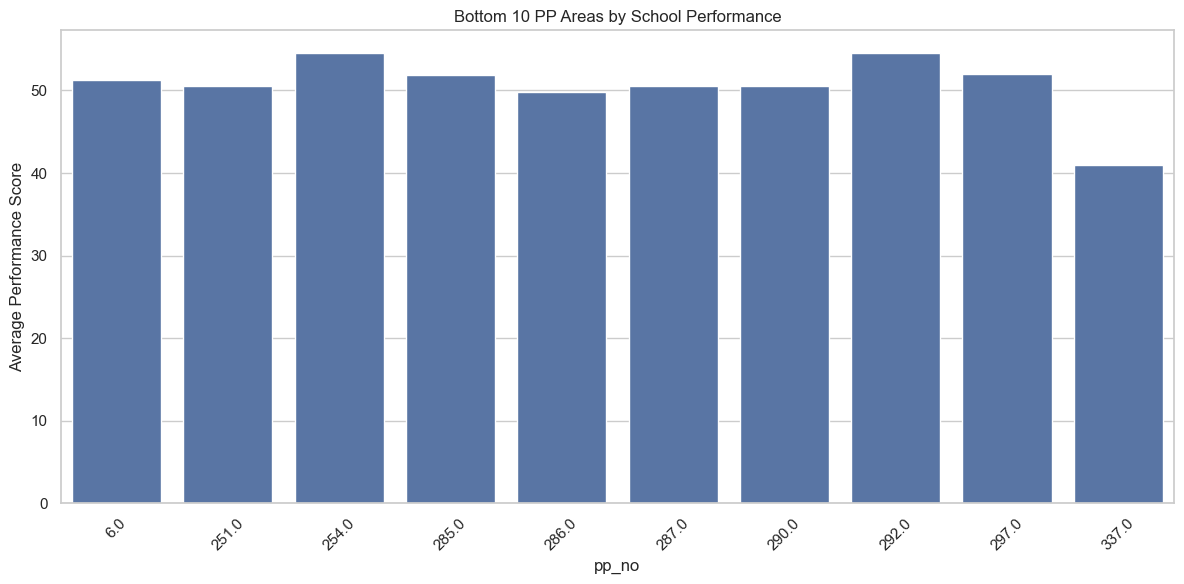

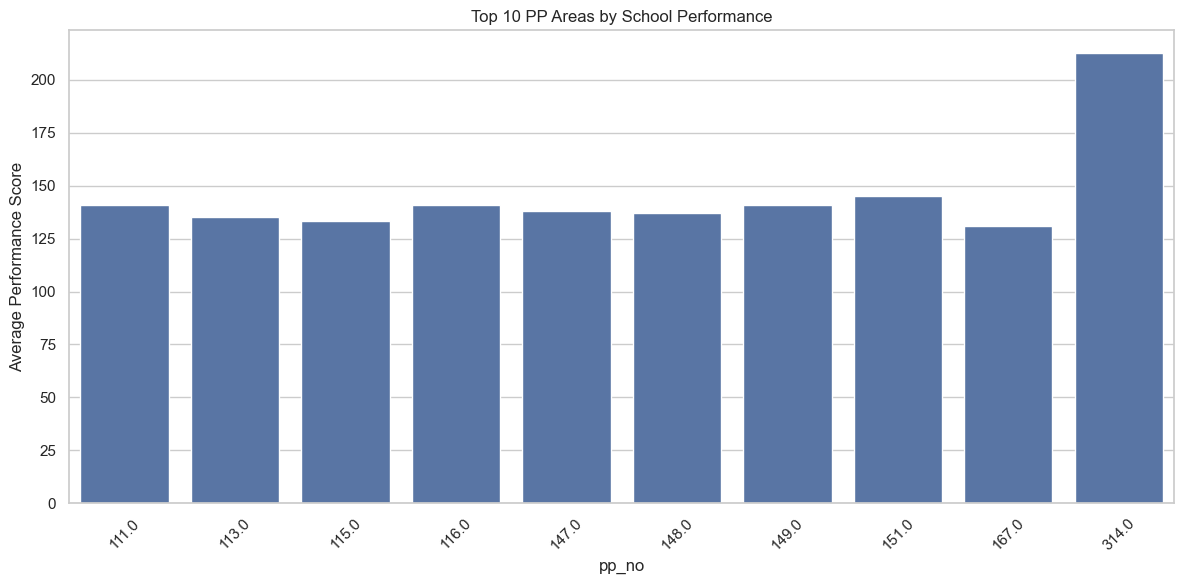

In [ ]:
# --------------------------------------------------------------
# NA-WISE PERFORMANCE SCORE ANALYSIS
# --------------------------------------------------------------

NA_COL = "pp_no"   # <<< CHANGE THIS if your column name is different

# Compute mean score per NA
na_scores = df.groupby(NA_COL)["performance_score"].mean().sort_values()

# -------------------------------
# BOTTOM 10 NA (Worst performing)
# -------------------------------
bottom10_na = na_scores.head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=bottom10_na.index, y=bottom10_na.values)
plt.title("Bottom 10 PP Areas by School Performance")
plt.ylabel("Average Performance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------
# TOP 10 NA (Best performing)
# -------------------------------
top10_na = na_scores.tail(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top10_na.index, y=top10_na.values)
plt.title("Top 10 PP Areas by School Performance")
plt.ylabel("Average Performance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



SCHOOLS APPEARING IN MAX CATEGORIES (TOP or BOTTOM): 6
       school_id                              school_name     district  pp_no
5311     16230.0              GGHSS CHAK 202 RB GATTI FSD   FAISALABAD  116.0
9062     20393.0             GHS COMPREHENSIVE GUJRANWALA   GUJRANWALA   57.0
10402    31912.0    GGHS MC MODEL AKBER BAZAR SHEIKHUPURA  SHEIKHUPURA  133.0
11156     9563.0                            GGPS ISPLANGI    D.G. KHAN  285.0
23356    35023.0                    GHS MC MODEL BUREWALA       VEHARI  233.0
39815    22823.0  GGHS MUNCIPAL MODEL AKRAM ALI KHAN ROAD       GUJRAT   31.0


/var/folders/0x/rx6z5n5d6dzbfbmmrfbxwsdw0000gn/T/ipykernel_79098/3701261736.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', len(unique_districts))


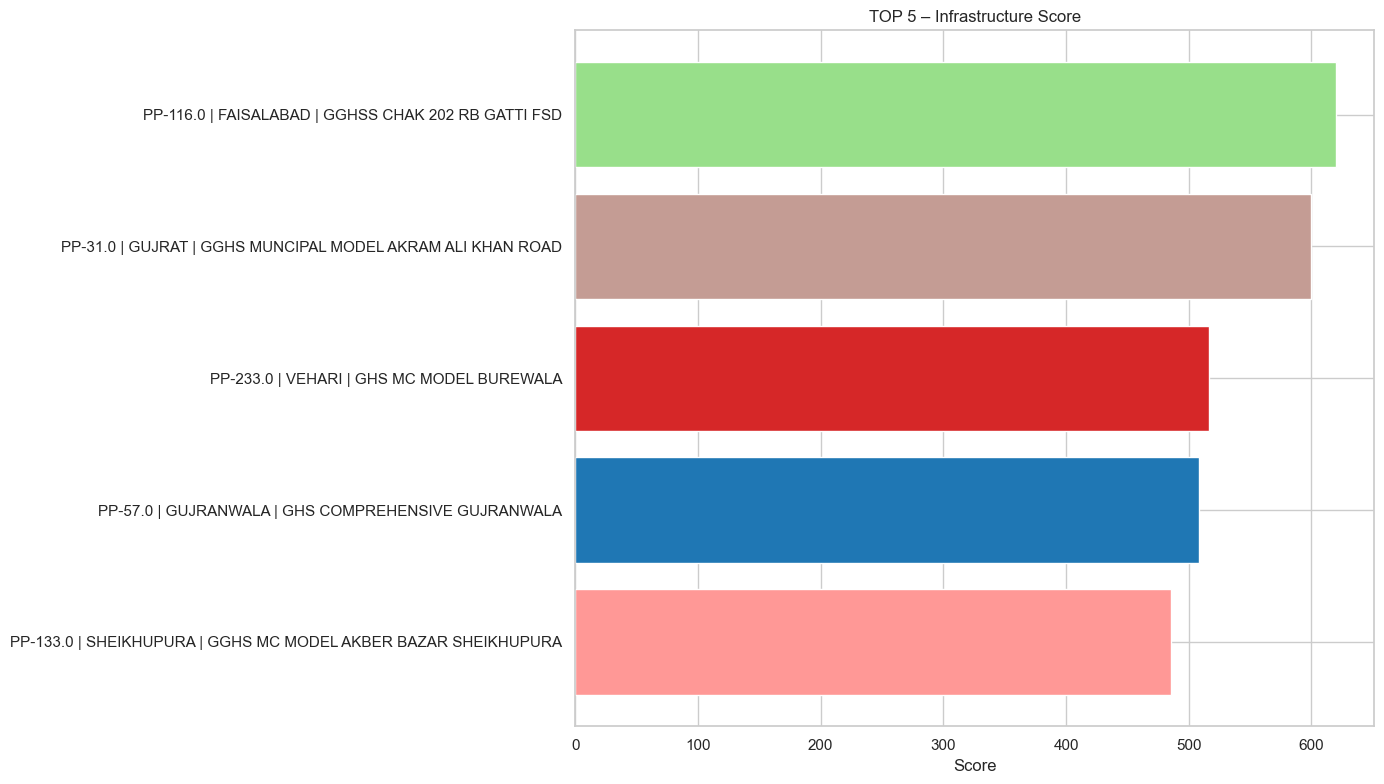

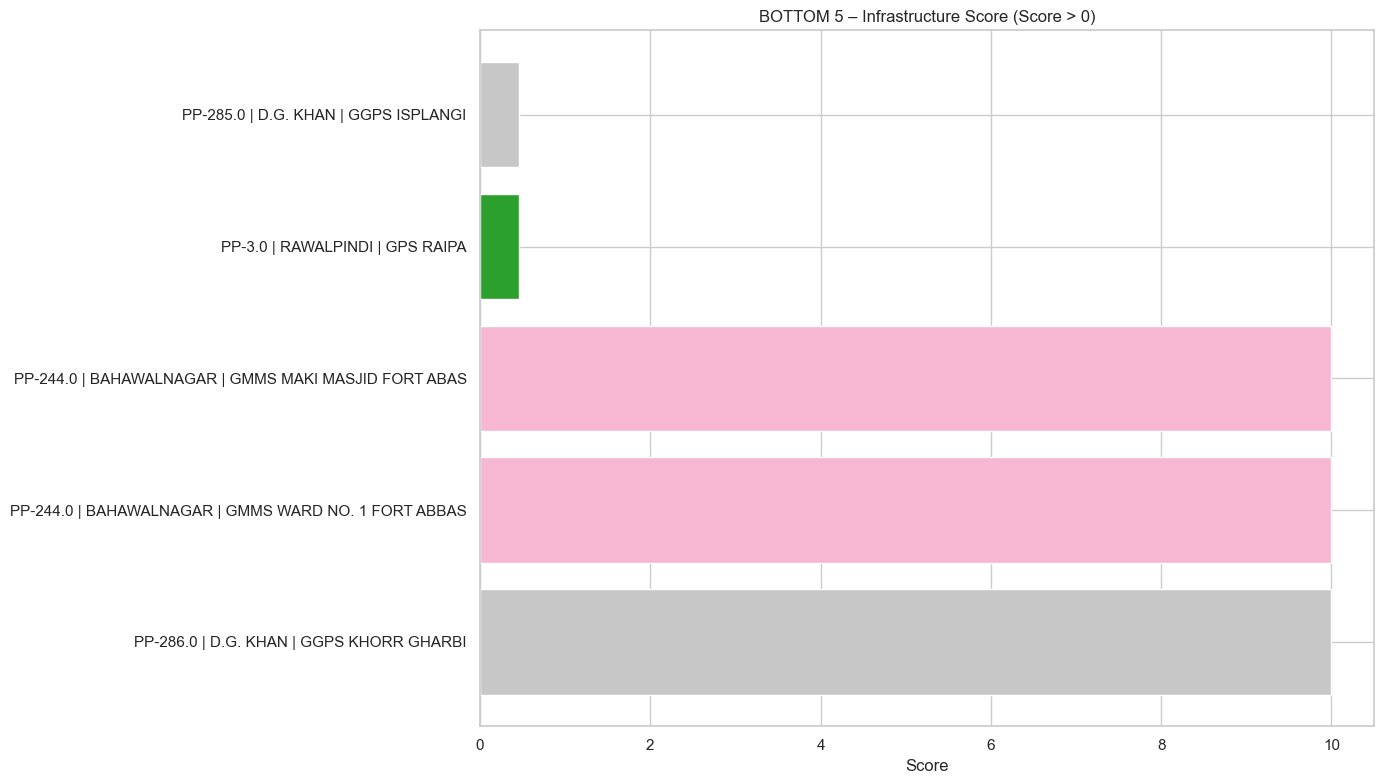

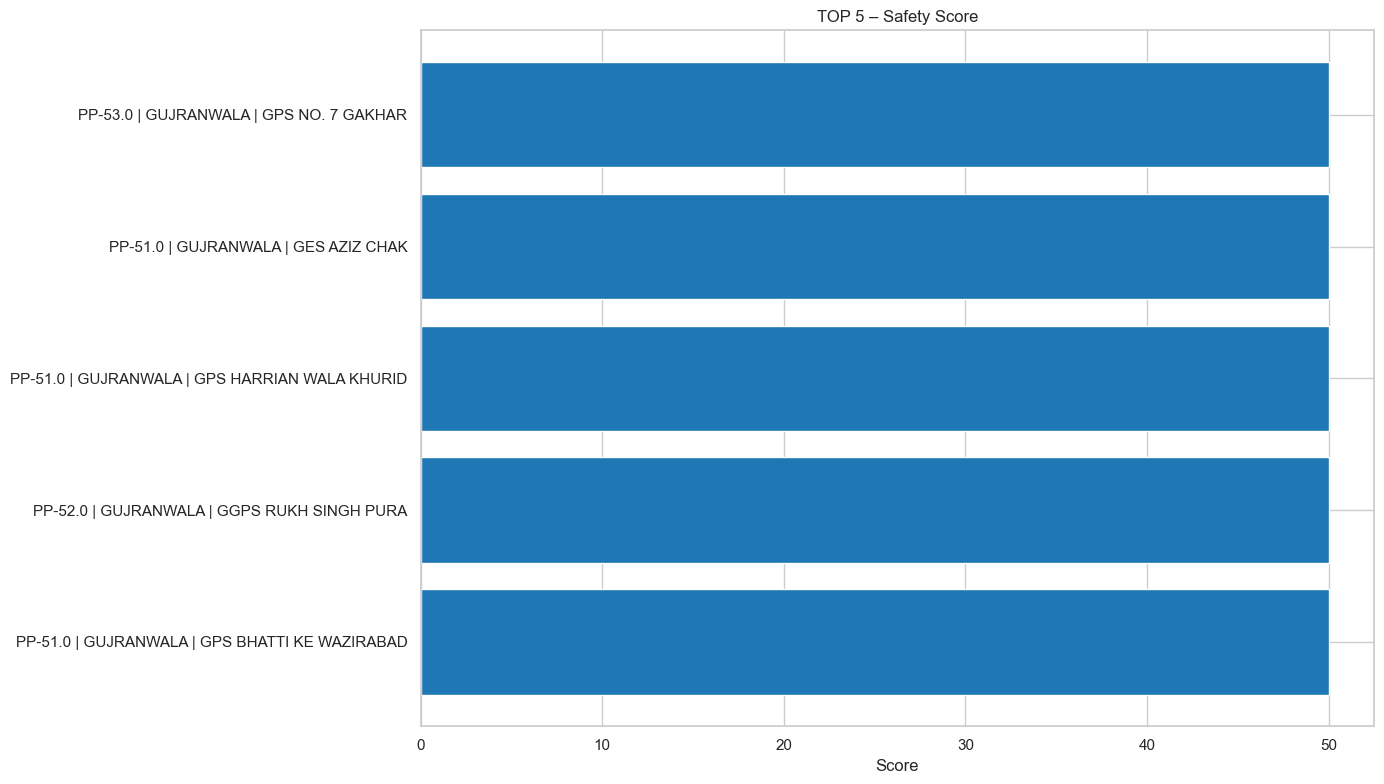

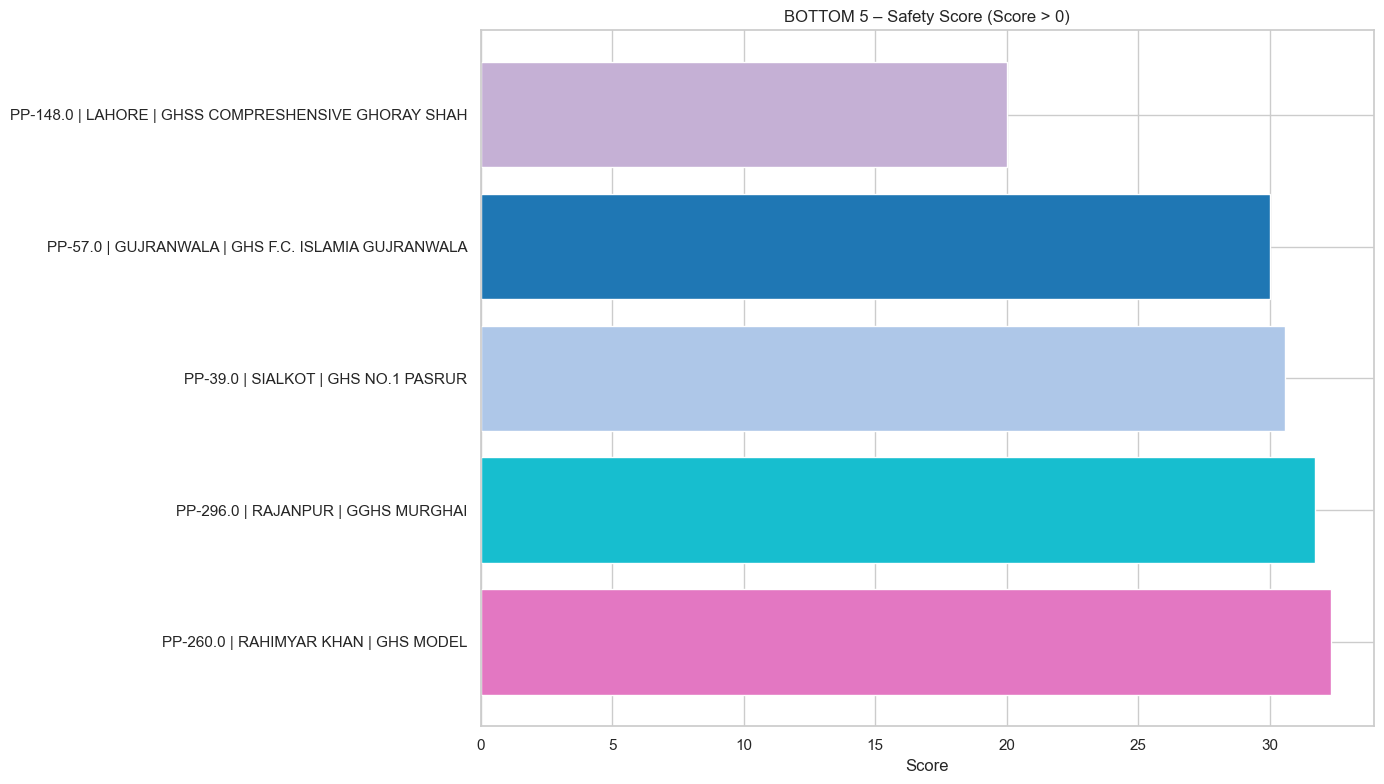

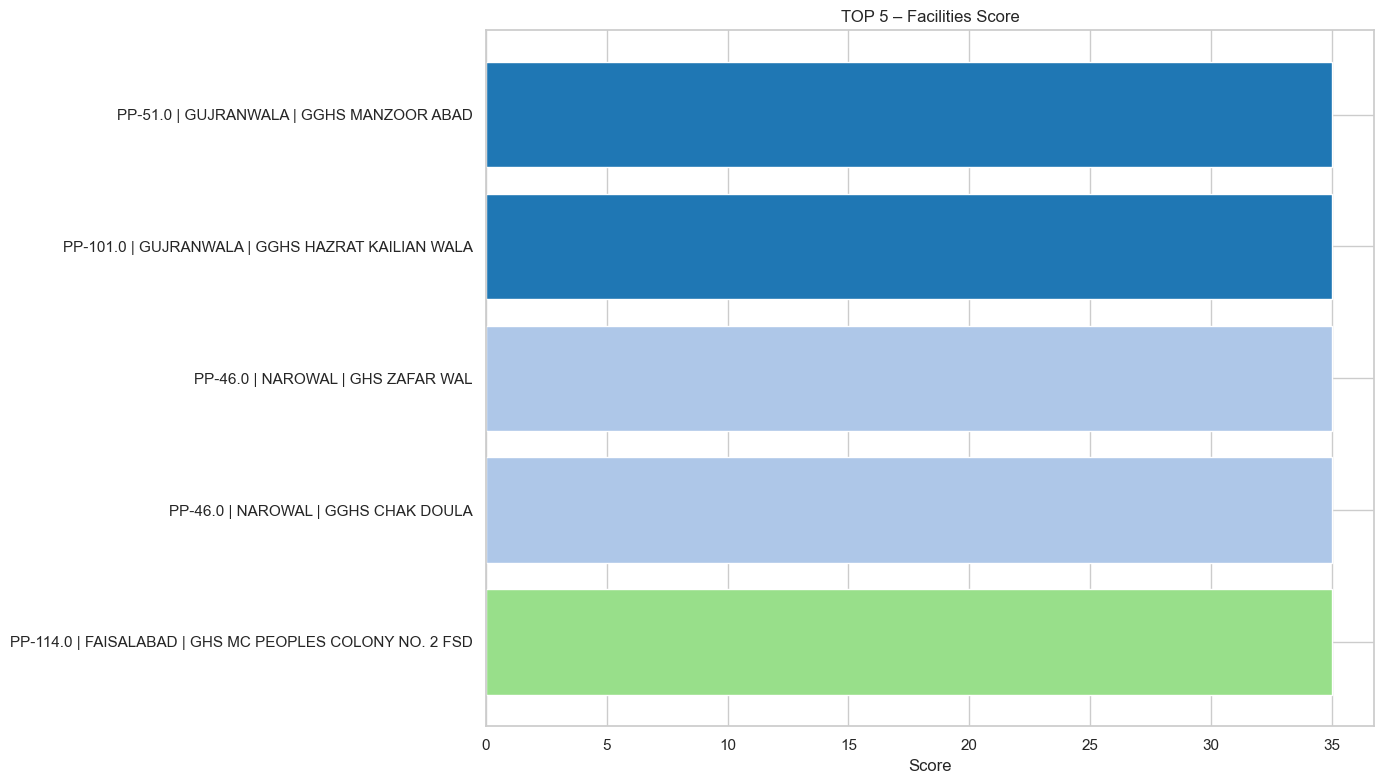

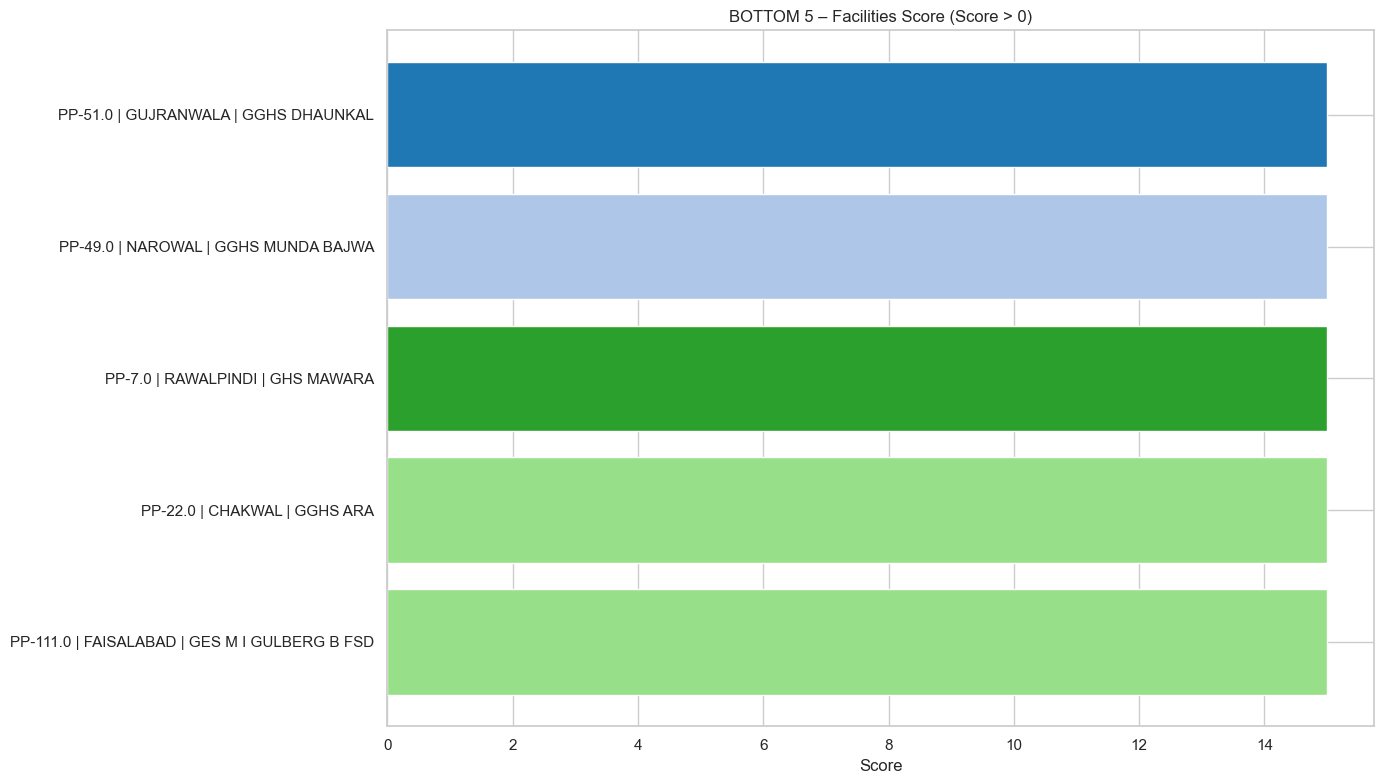

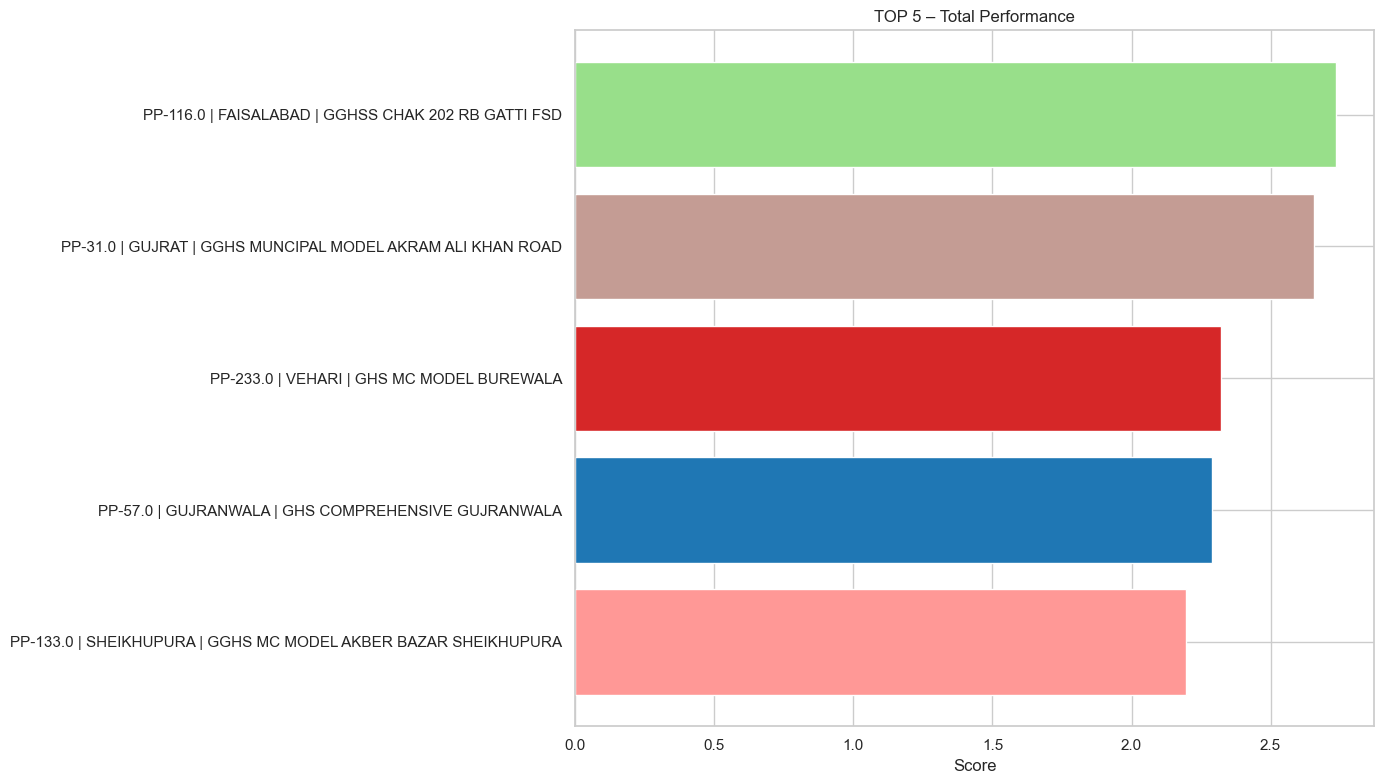

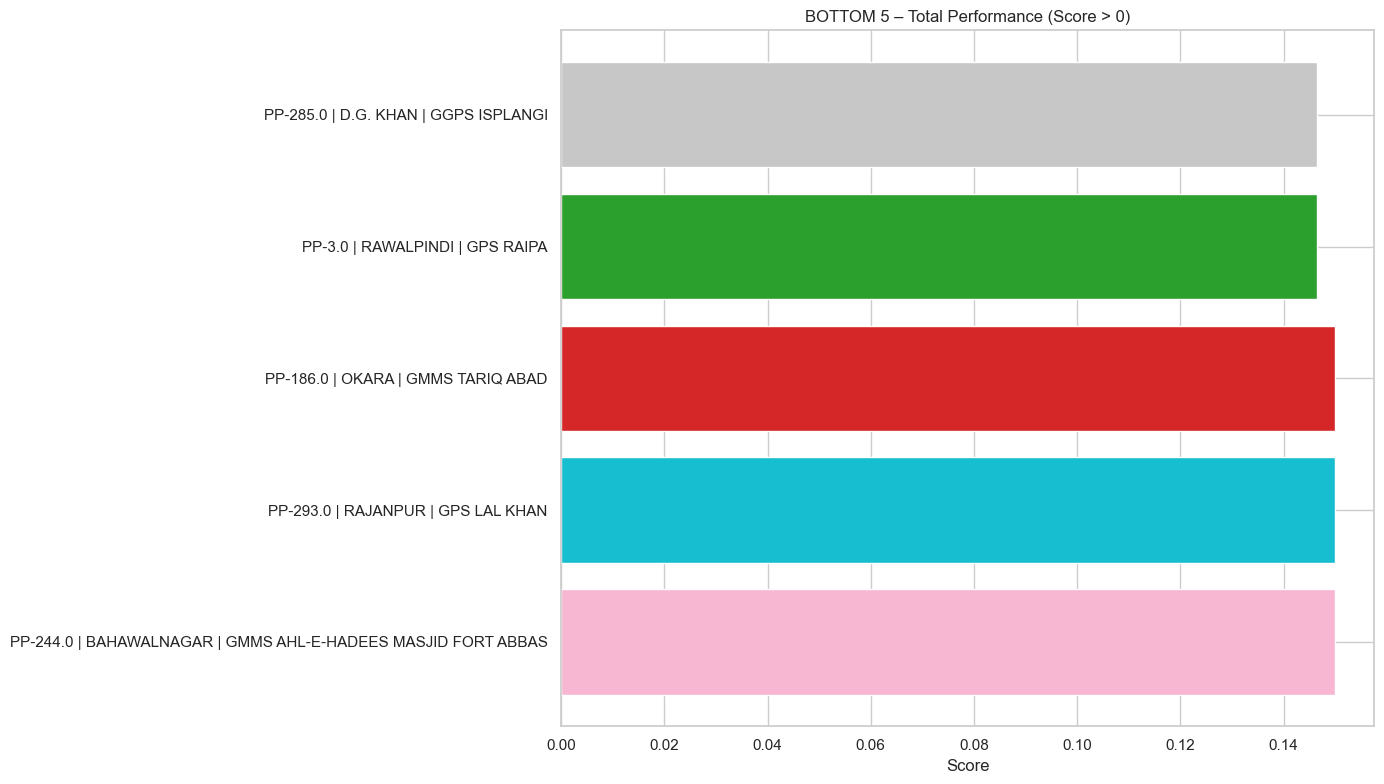

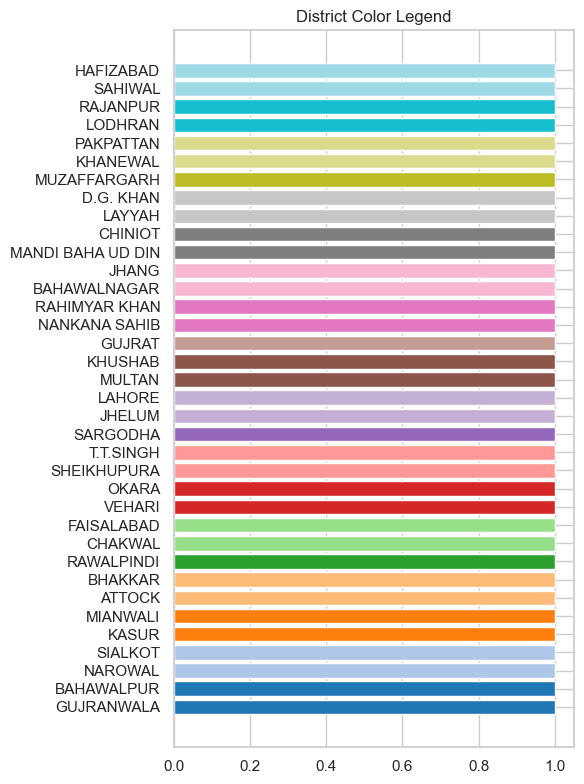

In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ----------------------------------------------------------
# NORMALIZATION FUNCTION
# ----------------------------------------------------------
def normalize(series):
    series = pd.to_numeric(series, errors="coerce").fillna(0)
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

# ----------------------------------------------------------
# SCORE CALCULATIONS
# ----------------------------------------------------------
df["Infrastructure_Score"] = (
    0.20 * normalize(df["total_rooms"]) +
    0.20 * normalize(df["functional_classrooms"] / df["total_rooms"].replace(0,1)) +
    0.20 * df["electricity"].fillna(0) +
    0.20 * df["drink_water"].fillna(0) +
    0.10 * df["usable_toilets"].fillna(0) +
    0.10 * df["main_gate"].fillna(0)
) * 100

df["Safety_Score"] = (
    0.30 * (1 - normalize(df["dangerous_classrooms"])) +
    0.20 * (1 - normalize(df["dangerous_non_classrooms"])) +
    0.20 * df["boundary_wall_state"].fillna(0) +
    0.20 * df["main_gate"].fillna(0) +
    0.10 * df["security"].fillna(0)
) * 100

df["Facilities_Score"] = (
    0.20 * df["play_ground"].fillna(0) +
    0.20 * df["library"].fillna(0) +
    0.20 * df["science_lab"].fillna(0) +
    0.15 * df["computer_lab"].fillna(0) +
    0.15 * df["internet"].fillna(0)
) * 100

df["Total_Performance"] = (
    0.40 * df["Infrastructure_Score"] +
    0.30 * df["Safety_Score"] +
    0.30 * df["Facilities_Score"]
) / 100

# ----------------------------------------------------------
# FUNCTIONS FOR TOP/BOTTOM EXTRACTION (5 each)
# ----------------------------------------------------------
def get_top(df, col):
    return df.nlargest(5, col)

def get_bottom_nonzero(df, col):
    return df[df[col] > 0].nsmallest(5, col)

# ----------------------------------------------------------
# EXTRACT TOP/BOTTOM
# ----------------------------------------------------------
top_infra  = get_top(df, "Infrastructure_Score")
top_safety = get_top(df, "Safety_Score")
top_fac    = get_top(df, "Facilities_Score")
top_total  = get_top(df, "Total_Performance")

bottom_infra  = get_bottom_nonzero(df, "Infrastructure_Score")
bottom_safety = get_bottom_nonzero(df, "Safety_Score")
bottom_fac    = get_bottom_nonzero(df, "Facilities_Score")
bottom_total  = get_bottom_nonzero(df, "Total_Performance")

# ----------------------------------------------------------
# IDENTIFY SCHOOLS APPEARING MOST FREQUENTLY (TOP + BOTTOM)
# ----------------------------------------------------------
all_lists = (
    list(top_infra["school_id"]) +
    list(top_safety["school_id"]) +
    list(top_fac["school_id"]) +
    list(top_total["school_id"]) +
    list(bottom_infra["school_id"]) +
    list(bottom_safety["school_id"]) +
    list(bottom_fac["school_id"]) +
    list(bottom_total["school_id"])
)

freq = pd.Series(all_lists).value_counts()
max_freq = freq.max()
schools_in_most_categories = freq[freq == max_freq].index.tolist()

schools_in_most_categories_df = df[df["school_id"].isin(schools_in_most_categories)]

print("\nSCHOOLS APPEARING IN MAX CATEGORIES (TOP or BOTTOM):", len(schools_in_most_categories))
print(schools_in_most_categories_df[["school_id", "school_name", "district", "pp_no"]])

# ----------------------------------------------------------
# DISTRICT COLOR MAP
# ----------------------------------------------------------
unique_districts = df["district"].astype(str).unique()
colors = cm.get_cmap('tab20', len(unique_districts))

district_color_map = {
    district: mcolors.to_hex(colors(i))
    for i, district in enumerate(unique_districts)
}

# ----------------------------------------------------------
# PLOT FUNCTION WITH PP + DISTRICT + SCHOOL NAME + COLORS
# ----------------------------------------------------------
def plot_scores(data, col, title):
    data = data.copy()

    # FULL LABEL
    data["label"] = (
        "PP-" + data["pp_no"].astype(str) +
        " | " + data["district"].astype(str) +
        " | " + data["school_name"].astype(str)
    )

    # COLOR BY DISTRICT
    bar_colors = data["district"].map(district_color_map)

    plt.figure(figsize=(14, 8))
    plt.barh(data["label"], data[col], color=bar_colors)
    plt.xlabel("Score")
    plt.title(title)
    plt.tight_layout()
    plt.gca().invert_yaxis()
    plt.show()

# ----------------------------------------------------------
# PLOTS (TOP & BOTTOM FOR EACH CATEGORY)
# ----------------------------------------------------------

plot_scores(top_infra, "Infrastructure_Score", "TOP 5 – Infrastructure Score")
plot_scores(bottom_infra, "Infrastructure_Score", "BOTTOM 5 – Infrastructure Score (Score > 0)")

plot_scores(top_safety, "Safety_Score", "TOP 5 – Safety Score")
plot_scores(bottom_safety, "Safety_Score", "BOTTOM 5 – Safety Score (Score > 0)")

plot_scores(top_fac, "Facilities_Score", "TOP 5 – Facilities Score")
plot_scores(bottom_fac, "Facilities_Score", "BOTTOM 5 – Facilities Score (Score > 0)")

plot_scores(top_total, "Total_Performance", "TOP 5 – Total Performance")
plot_scores(bottom_total, "Total_Performance", "BOTTOM 5 – Total Performance (Score > 0)")

# ----------------------------------------------------------
# DISTRICT COLOR LEGEND
# ----------------------------------------------------------
plt.figure(figsize=(6, 8))
for district, color in district_color_map.items():
    plt.barh(district, 1, color=color)
plt.title("District Color Legend")
plt.tight_layout()
plt.show()
